#  Prediksi Customer Churn pada Nasabah Bank
## Menggunakan Algoritma Logistic Regression

---

| Info | Detail |
|------|--------|
| **Mata Kuliah** | Penggalian Data (Data Mining) |
| **Dataset** | Bank Customer Churn Dataset (Kaggle) |
| **Algoritma** | Logistic Regression (+ Decision Tree sebagai pembanding) |
| **Jenis Masalah** | Binary Classification |
| **Target Variable** | `Exited` (1 = Churn, 0 = Tidak Churn) |

---

###  Deskripsi Project
Project ini bertujuan untuk **memprediksi apakah seorang nasabah bank akan berhenti menggunakan layanan bank (churn)**
menggunakan pendekatan *supervised machine learning* dengan algoritma **Logistic Regression**.
Dengan model ini, pihak bank dapat mengidentifikasi nasabah yang berpotensi churn lebih awal dan mengambil tindakan preventif.


##  Instalasi Library & Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)

# Konfigurasi tampilan
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='Set2')

print(" Semua library berhasil diimport!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
import sklearn; print(f"   sklearn : {sklearn.__version__}")


 Semua library berhasil diimport!
   pandas  : 2.2.2
   numpy   : 2.0.2
   sklearn : 1.6.1



#  SECTION 1 — DATA UNDERSTANDING

## 1.1 Load Dataset


In [ ]:


df = pd.read_csv('churn.csv')   # Sesuaikan path jika diperlukan
print(f" Dataset berhasil dimuat!")
print(f"   Jumlah Baris   : {df.shape[0]:,}")
print(f"   Jumlah Kolom   : {df.shape[1]}")


 Dataset berhasil dimuat!
   Jumlah Baris   : 10,000
   Jumlah Kolom   : 14


## 1.2 Deskripsi Dataset

###  Informasi Umum Dataset

| Atribut | Keterangan |
|---------|-----------|
| **Nama Dataset** | Bank Customer Churn Dataset |
| **Sumber** | [Kaggle — mathchi/churn-for-bank-customers](https://www.kaggle.com/datasets/mathchi/churn-for-bank-customers) |
| **Jumlah Data** | 10.000 baris |
| **Jumlah Fitur** | 14 kolom (3 dihapus, 11 digunakan) |
| **Jenis Masalah** | Binary Classification |
| **Target Variable** | `Exited` (0 = Tidak Churn, 1 = Churn) |

---

###  Penjelasan Tiap Kolom / Fitur

| No | Kolom | Tipe Data | Deskripsi |
|----|-------|-----------|-----------|
| 1  | `RowNumber` | int | Nomor urut baris — **tidak relevan, akan dihapus** |
| 2  | `CustomerId` | int | ID unik nasabah — **tidak relevan, akan dihapus** |
| 3  | `Surname` | string | Nama belakang nasabah — **tidak relevan, akan dihapus** |
| 4  | `CreditScore` | int | Skor kredit nasabah (300–850) |
| 5  | `Geography` | string | Negara nasabah: France, Spain, Germany |
| 6  | `Gender` | string | Jenis kelamin: Male / Female |
| 7  | `Age` | int | Usia nasabah (tahun) |
| 8  | `Tenure` | int | Lama menjadi nasabah (tahun) |
| 9  | `Balance` | float | Saldo rekening nasabah (USD) |
| 10 | `NumOfProducts` | int | Jumlah produk bank yang dimiliki |
| 11 | `HasCrCard` | int | Memiliki kartu kredit? (1=Ya, 0=Tidak) |
| 12 | `IsActiveMember` | int | Nasabah aktif? (1=Ya, 0=Tidak) |
| 13 | `EstimatedSalary` | float | Estimasi gaji tahunan nasabah (USD) |
| 14 | `Exited` | int | **TARGET** — Churn? (1=Ya/Churn, 0=Tidak) |

---

###  Apa itu Customer Churn?

**Churn** (atau *customer attrition*) adalah kondisi di mana seorang nasabah/pelanggan **berhenti menggunakan layanan** suatu perusahaan.
Dalam konteks dataset ini, nasabah dikatakan **churn** apabila kolom `Exited = 1`, artinya nasabah tersebut **menutup rekeningnya** atau **tidak lagi menggunakan layanan bank**.

Churn merupakan permasalahan serius bagi industri perbankan karena:
- Biaya akuisisi nasabah baru jauh lebih mahal daripada mempertahankan yang lama
- Kehilangan nasabah loyal berdampak pada penurunan pendapatan jangka panjang
- Identifikasi dini memungkinkan bank memberikan penawaran retensi yang tepat sasaran


In [ ]:
print("=== df.head() ===")
df.head()


=== df.head() ===


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print("=== df.info() ===")
df.info()


=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
print("=== df.describe() ===")
df.describe().round(2)


=== df.describe() ===


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,5000.50,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,2886.90,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,1.00,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,2500.75,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,5000.50,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,7500.25,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,10000.00,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [ ]:
print(f"Dimensi Dataset : {df.shape}")
print(f"\nNama Kolom      :")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")


Dimensi Dataset : (10000, 14)

Nama Kolom      :
   1. RowNumber
   2. CustomerId
   3. Surname
   4. CreditScore
   5. Geography
   6. Gender
   7. Age
   8. Tenure
   9. Balance
  10. NumOfProducts
  11. HasCrCard
  12. IsActiveMember
  13. EstimatedSalary
  14. Exited



#  SECTION 2 — DATA PREPROCESSING

Preprocessing adalah tahap pembersihan dan transformasi data mentah agar siap digunakan oleh model machine learning.
Berikut tahapan yang dilakukan secara berurutan.


## 2.1 Cek Missing Value

In [ ]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
print("=== Cek Missing Value ===")
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else " Tidak ada missing value!")


=== Cek Missing Value ===
 Tidak ada missing value!


**Interpretasi:** Dataset ini tidak memiliki missing value sehingga tidak diperlukan proses imputasi data.


## 2.2 Cek Data Duplikat

In [ ]:
# Cek data duplikat
dup = df.duplicated().sum()
print(f"Jumlah data duplikat : {dup}")
print("✅ Tidak ada data duplikat!" if dup == 0 else f"⚠️  Ditemukan {dup} baris duplikat.")


**Interpretasi:** Tidak ada data duplikat sehingga seluruh 10.000 baris dapat digunakan.


## 2.3 Hapus Kolom yang Tidak Relevan

In [ ]:
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']

print("Kondisi sebelum penghapusan kolom:")
print(f"  Shape : {df.shape}  |  Kolom : {df.columns.tolist()}\n")

df = df.drop(columns=cols_to_drop)

print("Kondisi setelah penghapusan kolom:")
print(f"  Shape : {df.shape}  |  Kolom : {df.columns.tolist()}")


Kondisi sebelum penghapusan kolom:
  Shape : (10000, 14)  |  Kolom : ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Kondisi setelah penghapusan kolom:
  Shape : (10000, 11)  |  Kolom : ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


**Alasan penghapusan kolom:**
- `RowNumber` — hanya nomor urut, tidak mengandung informasi apapun tentang nasabah
- `CustomerId` — ID unik tiap nasabah, tidak berkorelasi dengan churn
- `Surname` — nama belakang nasabah, tidak relevan secara statistik untuk prediksi


## 2.4 Encoding Data Kategorikal

In [ ]:
print("Kolom kategorikal sebelum encoding:")
print(df.select_dtypes(include='object').head(3))
print()

# --- Label Encoding untuk Gender (Binary: Male=1, Female=0) ---
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
print(" Label Encoding 'Gender' selesai  (Male=1, Female=0)")

# --- One Hot Encoding untuk Geography (3 kategori: France, Spain, Germany) ---
df = pd.get_dummies(df, columns=['Geography'], drop_first=False, dtype=int)
print(" One Hot Encoding 'Geography' selesai")
print("   Kolom baru:", [c for c in df.columns if 'Geography' in c])

print(f"\nShape setelah encoding : {df.shape}")
df.head()


Kolom kategorikal sebelum encoding:
  Geography  Gender
0    France  Female
1     Spain  Female
2    France  Female

 Label Encoding 'Gender' selesai  (Male=1, Female=0)
 One Hot Encoding 'Geography' selesai
   Kolom baru: ['Geography_France', 'Geography_Germany', 'Geography_Spain']

Shape setelah encoding : (10000, 13)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1


**Penjelasan Encoding:**

| Kolom | Metode | Alasan |
|-------|--------|--------|
| `Gender` | **Label Encoding** (Male=1, Female=0) | Hanya 2 kategori (biner), tidak ada hubungan ordinal yang misleading |
| `Geography` | **One Hot Encoding** | Memiliki 3 kategori tanpa hubungan ordinal; One Hot menghindari bias numerik |


In [ ]:
print("=== DATA SETELAH PREPROCESSING ===")
print(f"Shape  : {df.shape}")
print(f"Kolom  : {df.columns.tolist()}")
print()
df.head()


=== DATA SETELAH PREPROCESSING ===
Shape  : (10000, 13)
Kolom  : ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']



,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1



#  SECTION 3 — EXPLORATORY DATA ANALYSIS (EDA)

EDA dilakukan untuk memahami pola, distribusi, dan hubungan antar variabel dalam dataset sebelum membangun model.


## 3.1 Distribusi Churn (Target Variable)

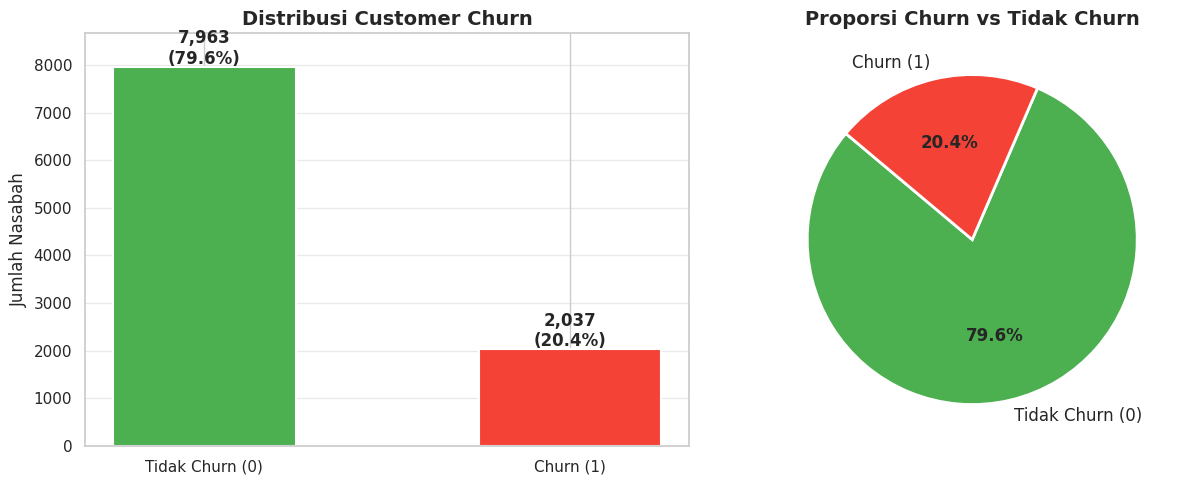


Jumlah Tidak Churn : 7,963 (79.6%)
Jumlah Churn       : 2,037 (20.4%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

churn_counts = df['Exited'].value_counts()
labels = ['Tidak Churn (0)', 'Churn (1)']
colors = ['#4CAF50', '#F44336']

# Bar chart
axes[0].bar(labels, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribusi Customer Churn', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Nasabah')
axes[0].set_ylim(0, churn_counts.max() + 700)
axes[0].grid(axis='y', alpha=0.4)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[1].set_title('Proporsi Churn vs Tidak Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nJumlah Tidak Churn : {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"Jumlah Churn       : {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)")


** Interpretasi:**
- Dataset menunjukkan **ketidakseimbangan kelas (*class imbalance*)** — sebanyak **79.6% nasabah tidak churn** dan hanya **20.4% nasabah churn**.
- Ketidakseimbangan ini penting diperhatikan dalam evaluasi model; accuracy saja tidak cukup — kita juga harus memperhatikan **precision, recall, dan F1-score** khususnya untuk kelas churn (1).


## 3.2 Distribusi Usia (Age) vs Churn

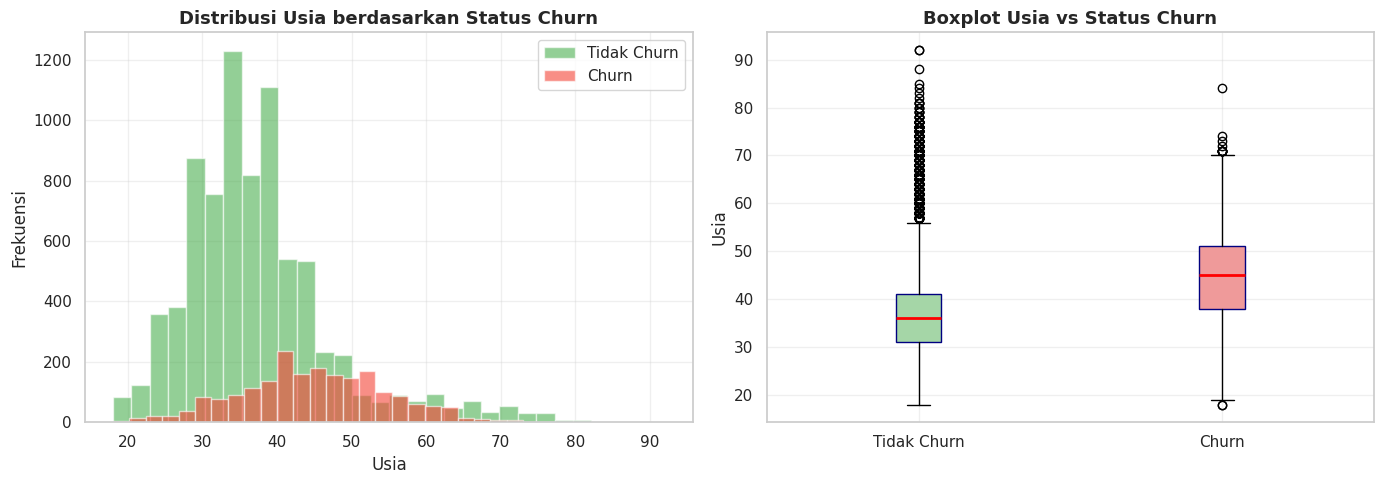

Statistik Usia berdasarkan Status Churn:
         count   mean    std   min   25%   50%   75%   max
Exited                                                    
0       7963.0  37.41  10.13  18.0  31.0  36.0  41.0  92.0
1       2037.0  44.84   9.76  18.0  38.0  45.0  51.0  84.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram distribusi usia berdasarkan status churn
for status, color, label in [(0, '#4CAF50', 'Tidak Churn'), (1, '#F44336', 'Churn')]:
    axes[0].hist(df[df['Exited'] == status]['Age'], bins=30, alpha=0.6,
                 color=color, label=label, edgecolor='white')
axes[0].set_title('Distribusi Usia berdasarkan Status Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
df_plot = df[['Age', 'Exited']].copy()
df_plot['Status'] = df_plot['Exited'].map({0: 'Tidak Churn', 1: 'Churn'})
bp = axes[1].boxplot(
    [df[df['Exited'] == 0]['Age'], df[df['Exited'] == 1]['Age']],
    labels=['Tidak Churn', 'Churn'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='navy'),
    medianprops=dict(color='red', linewidth=2)
)
bp['boxes'][0].set_facecolor('#A5D6A7')
bp['boxes'][1].set_facecolor('#EF9A9A')
axes[1].set_title('Boxplot Usia vs Status Churn', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Usia')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plot_02_age_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("Statistik Usia berdasarkan Status Churn:")
print(df.groupby('Exited')['Age'].describe().round(2))


** Interpretasi:**
- Nasabah yang **churn cenderung berusia lebih tua** (median ~45 tahun) dibandingkan yang tidak churn (median ~37 tahun).
- Kelompok usia **40–60 tahun** memiliki proporsi churn yang lebih tinggi.
- Usia merupakan **fitur penting** dalam memprediksi churn — nasabah yang lebih tua mungkin beralih ke layanan perbankan lain atau pensiun dari penggunaan aktif.


## 3.3 Distribusi Balance vs Churn

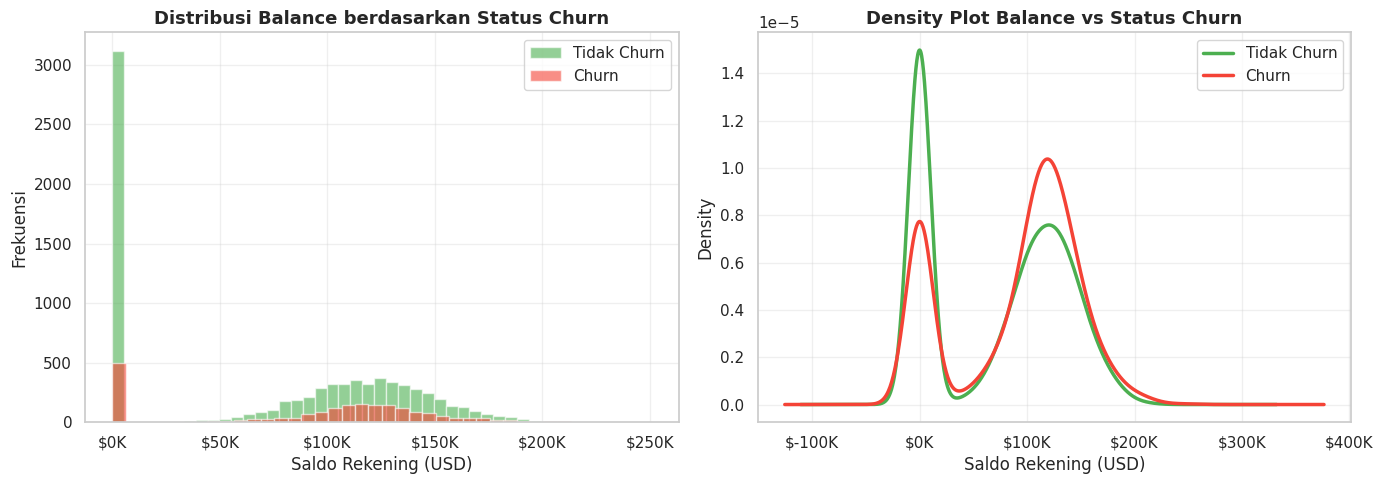

Statistik Balance berdasarkan Status Churn:
         count      mean       std  min       25%        50%        75%  \
Exited                                                                    
0       7963.0  72745.30  62848.04  0.0      0.00   92072.68  126410.28   
1       2037.0  91108.54  58360.79  0.0  38340.02  109349.29  131433.33   

              max  
Exited             
0       221532.80  
1       250898.09  


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram balance
for status, color, label in [(0, '#4CAF50', 'Tidak Churn'), (1, '#F44336', 'Churn')]:
    axes[0].hist(df[df['Exited'] == status]['Balance'], bins=40, alpha=0.6,
                 color=color, label=label, edgecolor='white')
axes[0].set_title('Distribusi Balance berdasarkan Status Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Saldo Rekening (USD)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].grid(alpha=0.3)

# KDE Plot
for status, color, label in [(0, '#4CAF50', 'Tidak Churn'), (1, '#F44336', 'Churn')]:
    subset = df[df['Exited'] == status]['Balance']
    subset.plot(kind='kde', ax=axes[1], color=color, label=label, linewidth=2.5)
axes[1].set_title('Density Plot Balance vs Status Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Saldo Rekening (USD)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plot_03_balance_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("Statistik Balance berdasarkan Status Churn:")
print(df.groupby('Exited')['Balance'].describe().round(2))


** Interpretasi:**
- Terdapat pola menarik: nasabah yang **churn memiliki saldo lebih tinggi** secara rata-rata (~$91K vs ~$72K).
- Banyak nasabah **tidak churn yang memiliki saldo nol** (kemungkinan rekening tabungan kosong tetapi tetap aktif menggunakan produk lain).
- Nasabah dengan saldo tinggi namun tetap churn mengindikasikan bahwa faktor kepuasan layanan dan produk mungkin lebih dominan dari saldo.


## 3.4 Nasabah Aktif (IsActiveMember) vs Churn

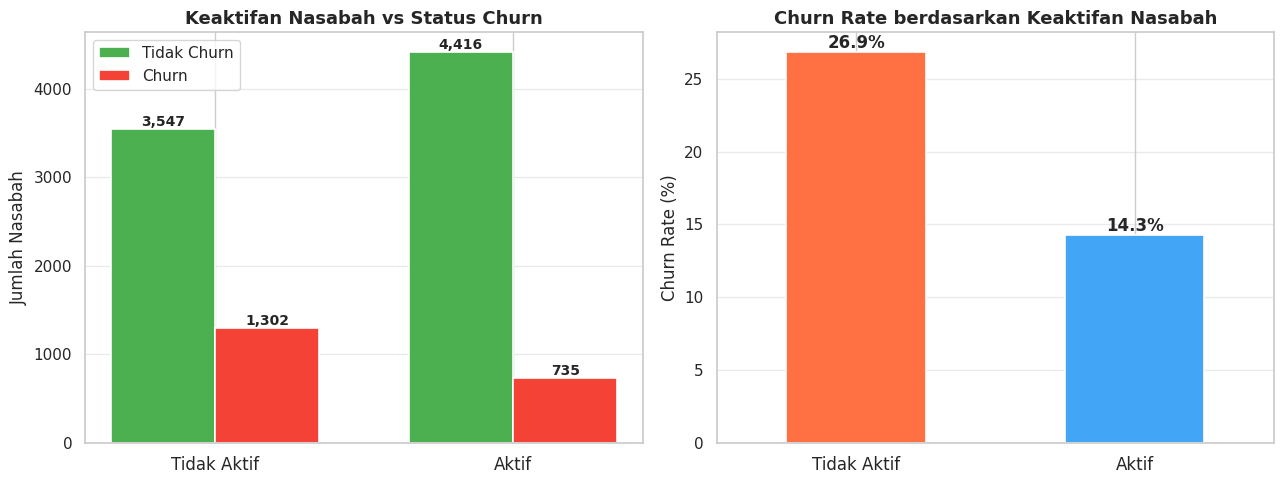

Churn Rate berdasarkan Status Keaktifan:
IsActiveMember
0    26.85
1    14.27


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grouped bar chart: Active Member vs Churn
active_churn = df.groupby(['IsActiveMember', 'Exited']).size().unstack()
active_churn.index = ['Tidak Aktif', 'Aktif']
active_churn.columns = ['Tidak Churn', 'Churn']

x = np.arange(len(active_churn.index))
width = 0.35
bars1 = axes[0].bar(x - width/2, active_churn['Tidak Churn'], width, label='Tidak Churn',
                    color='#4CAF50', edgecolor='white', linewidth=1.2)
bars2 = axes[0].bar(x + width/2, active_churn['Churn'], width, label='Churn',
                    color='#F44336', edgecolor='white', linewidth=1.2)
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(active_churn.index, fontsize=12)
axes[0].set_title('Keaktifan Nasabah vs Status Churn', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Nasabah')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

# Churn rate per active status
churn_rate = df.groupby('IsActiveMember')['Exited'].mean() * 100
churn_rate.index = ['Tidak Aktif', 'Aktif']
churn_rate.plot(kind='bar', ax=axes[1], color=['#FF7043', '#42A5F5'],
                edgecolor='white', linewidth=1.2, width=0.5)
for i, v in enumerate(churn_rate.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Churn Rate berdasarkan Keaktifan Nasabah', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].set_xticklabels(churn_rate.index, rotation=0, fontsize=12)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('plot_04_active_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("Churn Rate berdasarkan Status Keaktifan:")
print(df.groupby('IsActiveMember')['Exited'].mean().mul(100).round(2).to_string())


** Interpretasi:**
- **Nasabah yang tidak aktif** memiliki churn rate sebesar ~**26.9%**, hampir **2x lebih tinggi** dibandingkan nasabah aktif (~**14.3%**).
- Ini adalah insight penting: **keaktifan nasabah merupakan prediktor kuat untuk churn**.
- Bank sebaiknya fokus meningkatkan engagement nasabah yang tidak aktif melalui program loyalitas atau penawaran produk baru.


## 3.5 Visualisasi Tambahan: Geography & NumOfProducts vs Churn

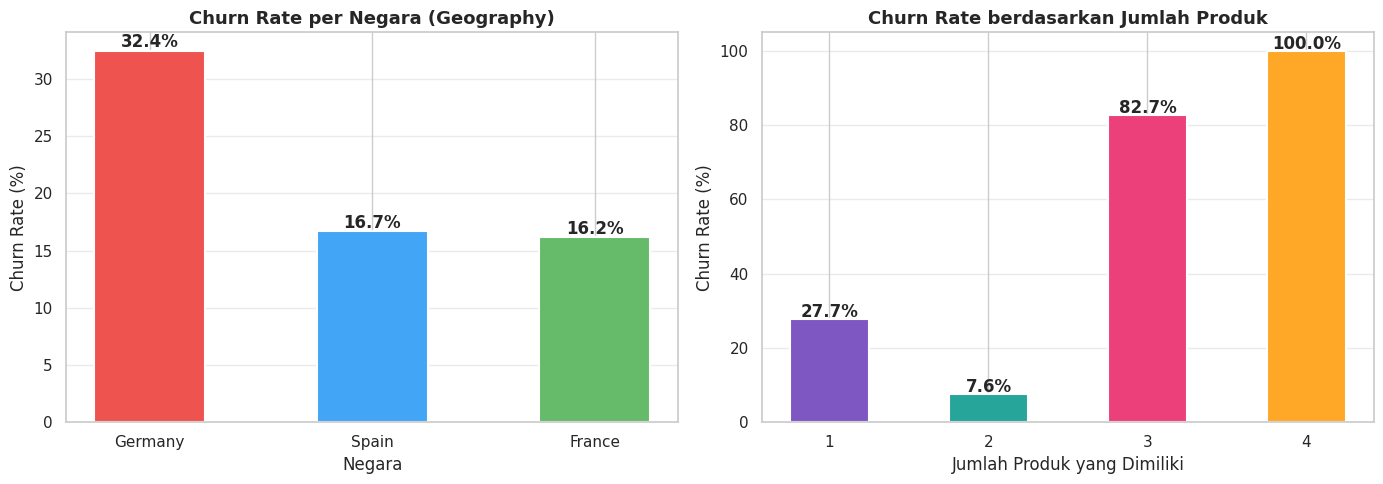

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Geography vs Churn Rate ---
# Gunakan kolom Geography asli dari df sebelum encoding — buat ulang dari One Hot
geo_cols = [c for c in df.columns if c.startswith('Geography_')]
df['Geography_Label'] = df[geo_cols].idxmax(axis=1).str.replace('Geography_', '')

geo_churn = df.groupby('Geography_Label')['Exited'].mean() * 100
geo_churn = geo_churn.sort_values(ascending=False)
bars = axes[0].bar(geo_churn.index, geo_churn.values,
                   color=['#EF5350', '#42A5F5', '#66BB6A'],
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Rate per Negara (Geography)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Negara')
axes[0].grid(axis='y', alpha=0.4)

# --- NumOfProducts vs Churn Rate ---
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
bars2 = axes[1].bar(prod_churn.index.astype(str), prod_churn.values,
                    color=['#7E57C2', '#26A69A', '#EC407A', '#FFA726'],
                    edgecolor='white', linewidth=1.5, width=0.5)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Churn Rate berdasarkan Jumlah Produk', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Jumlah Produk yang Dimiliki')
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('plot_05_geo_product_churn.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['Geography_Label'], inplace=True)  # Hapus kolom sementara


** Interpretasi:**
- **Germany** memiliki churn rate tertinggi (~**32%**), hampir 2x dibandingkan France (~16%) dan Spain (~17%).
- Nasabah dengan **4 produk** memiliki churn rate sangat tinggi (~**100%**!) — kemungkinan besar nasabah dengan banyak produk merasa overwhelmed atau tidak puas.
- Sebaliknya, nasabah dengan **2 produk** memiliki churn rate terendah (~**7.6%**) — sweet spot yang ideal.


## 3.6 Correlation Heatmap

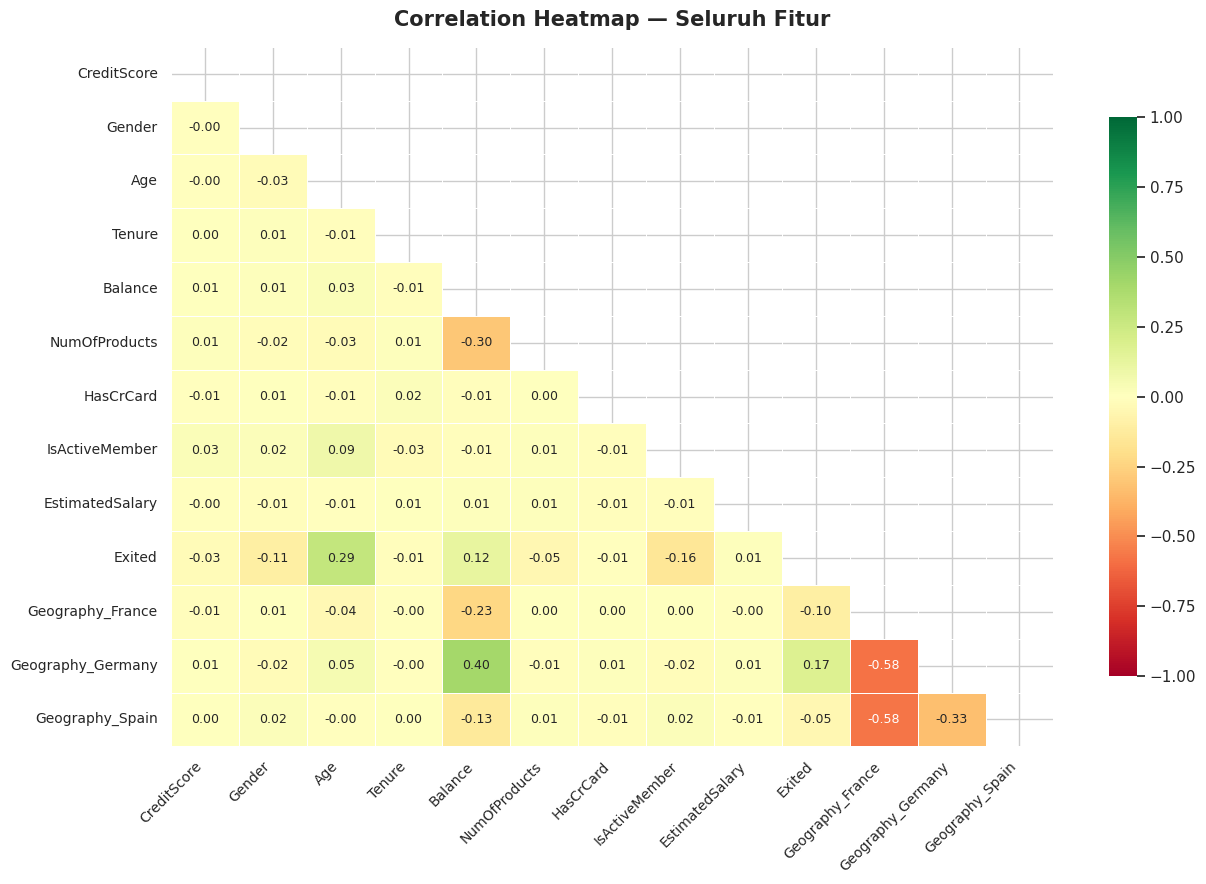


=== Korelasi Fitur terhadap Target (Exited) ===
Age                  0.2853
Geography_Germany    0.1735
IsActiveMember      -0.1561
Balance              0.1185
Gender              -0.1065
Geography_France    -0.1050
Geography_Spain     -0.0527
NumOfProducts       -0.0478
CreditScore         -0.0271
Tenure              -0.0140
EstimatedSalary      0.0121
HasCrCard           -0.0071


In [ ]:
plt.figure(figsize=(13, 9))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
heatmap = sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Seluruh Fitur', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('plot_06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Korelasi dengan target Exited
print("\n=== Korelasi Fitur terhadap Target (Exited) ===")
corr_target = corr['Exited'].drop('Exited').sort_values(key=abs, ascending=False)
print(corr_target.round(4).to_string())


** Interpretasi:**
- **Age** memiliki korelasi positif tertinggi dengan Exited (±0.29) → nasabah yang lebih tua lebih cenderung churn
- **IsActiveMember** memiliki korelasi negatif kuat (±-0.16) → nasabah aktif lebih jarang churn
- **Balance** berkorelasi positif (±0.12) → saldo tinggi sedikit meningkatkan risiko churn
- **NumOfProducts** berkorelasi negatif (±-0.05) namun dengan pola non-linear (produk 4 = churn tinggi)
- Sebagian besar fitur memiliki korelasi rendah-sedang → Logistic Regression cukup tepat digunakan



# SECTION 4 — FEATURE SELECTION (Chi-Square)

## 4.1 Mengapa Feature Selection Penting?

**Feature Selection** adalah proses memilih subset fitur yang paling relevan dan informatif
dari keseluruhan fitur yang tersedia sebelum membangun model machine learning.

###  Tujuan Feature Selection:
| Tujuan | Penjelasan |
|--------|-----------|
| **Mengurangi noise** | Fitur tidak relevan dapat mengacaukan pola yang dipelajari model |
| **Mencegah overfitting** | Terlalu banyak fitur meningkatkan risiko model terlalu hafal data training |
| **Meningkatkan performa** | Fitur yang tepat dapat meningkatkan akurasi dan generalisasi model |
| **Efisiensi komputasi** | Lebih sedikit fitur = training lebih cepat |
| **Interpretabilitas** | Model lebih mudah dipahami dan dijelaskan |

---

###  Perbedaan Feature Selection vs Dimensionality Reduction (PCA)

| Aspek | Feature Selection (Chi-Square) | Dimensionality Reduction (PCA) |
|-------|-------------------------------|-------------------------------|
| **Cara Kerja** | Memilih fitur **asli** yang paling relevan berdasarkan uji statistik | Membuat fitur **baru** dari kombinasi linier fitur asli |
| **Interpretabilitas** |  Tinggi — fitur asli tetap bisa diinterpretasi |  Rendah — komponen baru sulit diinterpretasi bisnis |
| **Output** | Subset fitur asli (dimensi berkurang) | Komponen baru / Principal Components |
| **Kapan Digunakan** | Ketika ingin tahu fitur mana yang paling berpengaruh | Ketika dimensi sangat tinggi dan interpretasi bukan prioritas utama |
| **Mempertahankan info** | Fitur paling relevan saja | Mempertahankan % variansi tertentu dari semua fitur |


## 4.2 Persiapan Feature (X) dan Target (y)

In [ ]:
X = df.drop(columns=['Exited'])
y = df['Exited']

print("=== Feature dan Target ===")
print(f"Jumlah Fitur Awal : {X.shape[1]}")
print(f"Nama Fitur        : {X.columns.tolist()}")
print(f"Shape X           : {X.shape}")
print(f"\nTarget            : Exited")
print(f"Distribusi        : Tidak Churn (0)={(y==0).sum()} | Churn (1)={(y==1).sum()}")


=== Feature dan Target ===
Jumlah Fitur Awal : 12
Nama Fitur        : ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain']
Shape X           : (10000, 12)

Target            : Exited
Distribusi        : Tidak Churn (0)=7963 | Churn (1)=2037


## 4.3 Metode Feature Selection — Chi-Square Test (χ²)

###  Apa itu Chi-Square Test?

**Chi-Square (χ²)** adalah uji statistik non-parametrik yang mengukur
**tingkat ketergantungan (dependensi) antara dua variabel kategorikal**.
Dalam konteks feature selection, Chi-Square mengukur seberapa jauh
distribusi nilai suatu fitur **berbeda secara signifikan** antara kelas target (churn vs tidak churn).

###  Cara Kerja Chi-Square:
1. Hitung **frekuensi yang diobservasi** (O) — distribusi aktual fitur per kelas
2. Hitung **frekuensi yang diharapkan** (E) — jika fitur independen dari target
3. Hitung χ² = Σ [(O - E)² / E]
4. **χ² tinggi** → fitur sangat bergantung pada target → **relevan untuk prediksi**
5. **p-value < 0.05** → hubungan signifikan secara statistik

###  Syarat Chi-Square:
Chi-Square mengharuskan nilai fitur **non-negatif** (≥ 0).
Oleh karena itu, data harus dinormalisasi terlebih dahulu menggunakan **MinMaxScaler**
sebelum uji Chi-Square diterapkan.

| Langkah | Keterangan |
|---------|-----------|
| **MinMaxScaler** | Skala semua fitur ke rentang [0, 1] — memenuhi syarat Chi-Square |
| **chi2()** | Menghitung χ² score dan p-value untuk setiap fitur |
| **SelectKBest** | Memilih k fitur dengan χ² score tertinggi |


## 4.4 Normalisasi Data (MinMaxScaler)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)
X_mm_df = pd.DataFrame(X_mm, columns=X.columns)

print(" MinMaxScaler diterapkan — semua fitur sekarang dalam rentang [0, 1]")
print(f"   Shape : {X_mm_df.shape}")
print(f"\n   Min nilai fitur : {X_mm_df.min().min():.4f}")
print(f"   Max nilai fitur : {X_mm_df.max().max():.4f}")
print()
print("Sample 3 baris pertama setelah MinMaxScaler:")
print(X_mm_df.head(3).round(4).to_string())


 MinMaxScaler diterapkan — semua fitur sekarang dalam rentang [0, 1]
   Shape : (10000, 12)

   Min nilai fitur : 0.0000
   Max nilai fitur : 1.0000

Sample 3 baris pertama setelah MinMaxScaler:
   CreditScore  Gender     Age  Tenure  Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Geography_France  Geography_Germany  Geography_Spain
0        0.538     0.0  0.3243     0.2   0.0000         0.0000        1.0             1.0           0.5067               1.0                0.0              0.0
1        0.516     0.0  0.3108     0.1   0.3340         0.0000        0.0             1.0           0.5627               0.0                0.0              1.0
2        0.304     0.0  0.3243     0.8   0.6364         0.6667        1.0             0.0           0.5697               1.0                0.0              0.0


## 4.5 Uji Chi-Square — Ranking Fitur

In [ ]:
from sklearn.feature_selection import chi2, SelectKBest

# Hitung Chi-Square score dan p-value untuk setiap fitur
chi2_scores, chi2_pvals = chi2(X_mm, y)

# Buat DataFrame ranking
chi2_df = pd.DataFrame({
    'Fitur': X.columns,
    'Chi2 Score': chi2_scores,
    'P-Value': chi2_pvals
}).sort_values('Chi2 Score', ascending=False).reset_index(drop=True)
chi2_df.index += 1
chi2_df['Rank'] = range(1, len(chi2_df) + 1)
chi2_df['Signifikan (p<0.05)'] = chi2_df['P-Value'].apply(lambda p: ' Ya' if p < 0.05 else ' Tidak')

print("=== Ranking Fitur berdasarkan Chi-Square Score ===")
print(chi2_df[['Rank', 'Fitur', 'Chi2 Score', 'P-Value', 'Signifikan (p<0.05)']].to_string(index=False))


=== Ranking Fitur berdasarkan Chi-Square Score ===
 Rank             Fitur  Chi2 Score      P-Value Signifikan (p<0.05)
    1 Geography_Germany  225.464426 5.814572e-51                  Ya
    2    IsActiveMember  118.199414 1.568036e-27                  Ya
    3               Age   57.832080 2.854759e-14                  Ya
    4  Geography_France   54.923705 1.253006e-13                  Ya
    5            Gender   51.539926 7.015575e-13                  Ya
    6           Balance   28.502819 9.356218e-08                  Ya
    7   Geography_Spain   20.867206 4.922505e-06                  Ya
    8     NumOfProducts    4.863425 2.743182e-02                  Ya
    9       CreditScore    0.456316 4.993509e-01               Tidak
   10            Tenure    0.327054 5.673991e-01               Tidak
   11   EstimatedSalary    0.241805 6.229051e-01               Tidak
   12         HasCrCard    0.150041 6.984962e-01               Tidak


** Interpretasi Chi-Square Score:**
- **Chi2 score tinggi + p-value < 0.05** → fitur memiliki hubungan **signifikan** dengan target Exited
- **Chi2 score rendah + p-value > 0.05** → fitur **independen** dari target → kandidat untuk dihapus


## 4.6 Visualisasi Chi-Square Score

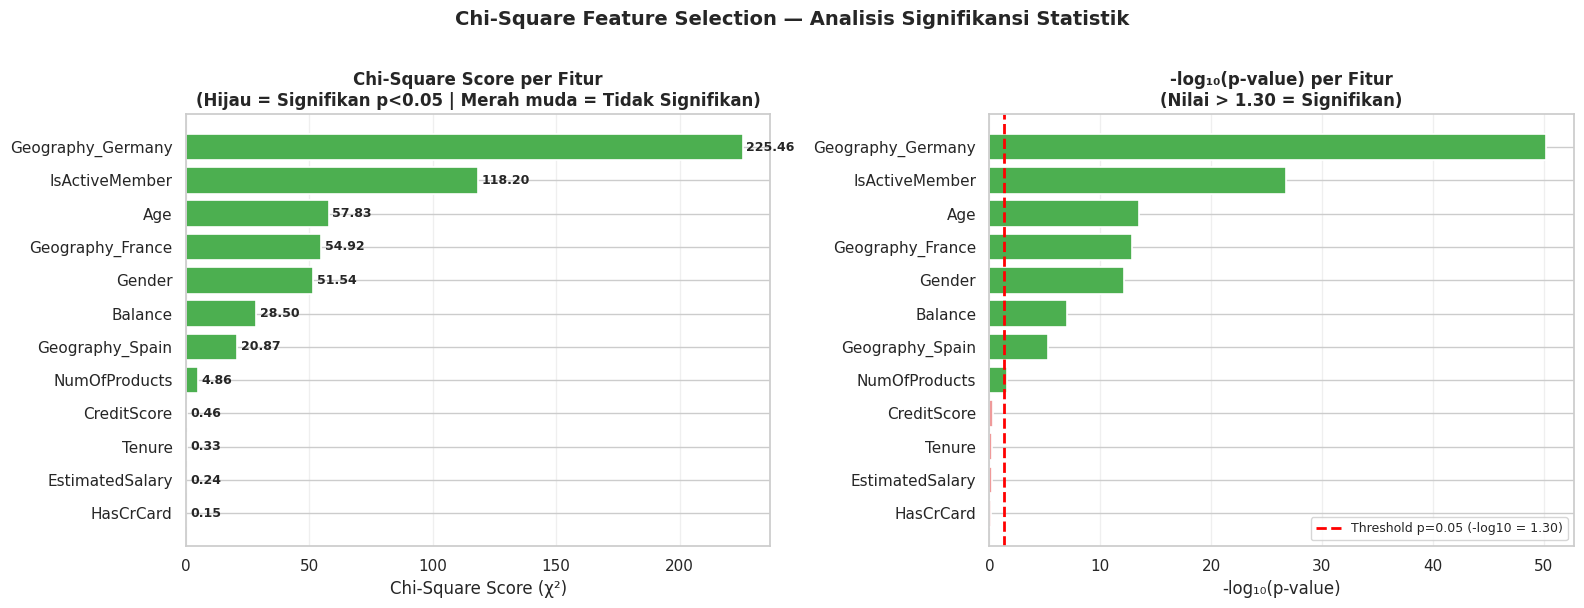

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel kiri: Chi2 Score bar chart
colors_chi = ['#4CAF50' if p < 0.05 else '#EF9A9A' for p in chi2_df['P-Value']]
bars_chi = axes[0].barh(
    chi2_df['Fitur'][::-1], chi2_df['Chi2 Score'][::-1],
    color=colors_chi[::-1], edgecolor='white', linewidth=1.2
)
axes[0].set_title('Chi-Square Score per Fitur\n(Hijau = Signifikan p<0.05 | Merah muda = Tidak Signifikan)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Chi-Square Score (χ²)')
axes[0].grid(axis='x', alpha=0.3)
for bar in bars_chi:
    axes[0].text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.2f}', va='center', fontsize=9, fontweight='bold')

# Panel kanan: -log10(p-value) untuk memperjelas signifikansi
log_pval = -np.log10(chi2_df['P-Value'].clip(lower=1e-300))
colors_p = ['#4CAF50' if p < 0.05 else '#EF9A9A' for p in chi2_df['P-Value']]
axes[1].barh(chi2_df['Fitur'][::-1], log_pval[::-1],
             color=colors_p[::-1], edgecolor='white', linewidth=1.2)
axes[1].axvline(-np.log10(0.05), color='red', linestyle='--', linewidth=2,
                label='Threshold p=0.05 (-log10 = 1.30)')
axes[1].set_title('-log₁₀(p-value) per Fitur\n(Nilai > 1.30 = Signifikan)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('-log₁₀(p-value)')
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Chi-Square Feature Selection — Analisis Signifikansi Statistik',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_chi2_scores.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.7 Seleksi Fitur — Pilih Fitur Signifikan (p < 0.05)

In [ ]:
# Pilih semua fitur dengan p-value < 0.05 (signifikan secara statistik)
significant_mask = chi2_pvals < 0.05
selected_features = X.columns[significant_mask].tolist()
dropped_features  = X.columns[~significant_mask].tolist()

print(f"=== Hasil Feature Selection (Chi-Square, p < 0.05) ===")
print(f"\n Fitur Terpilih ({len(selected_features)}) :")
for i, f in enumerate(selected_features, 1):
    idx = list(X.columns).index(f)
    print(f"   {i:2d}. {f:<25} χ²={chi2_scores[idx]:8.4f}   p={chi2_pvals[idx]:.6f}")

print(f"\n Fitur Dihapus ({len(dropped_features)}) :")
for f in dropped_features:
    idx = list(X.columns).index(f)
    print(f"       - {f:<25} χ²={chi2_scores[idx]:8.4f}   p={chi2_pvals[idx]:.6f}  → Tidak signifikan")

# Terapkan SelectKBest dengan k = jumlah fitur signifikan
K_BEST = len(selected_features)
selector_chi2 = SelectKBest(score_func=chi2, k=K_BEST)
X_chi2 = selector_chi2.fit_transform(X_mm, y)

print(f"\nShape sebelum Feature Selection : {X_mm.shape}")
print(f"Shape setelah Feature Selection  : {X_chi2.shape}")

# Simpan sebagai DataFrame (pakai MinMaxScaled values)
X_selected_df = pd.DataFrame(X_chi2, columns=selected_features)
print(f"\n X_selected_df siap — {K_BEST} fitur terpilih berdasarkan Chi-Square")


=== Hasil Feature Selection (Chi-Square, p < 0.05) ===

 Fitur Terpilih (8) :
    1. Gender                    χ²= 51.5399   p=0.000000
    2. Age                       χ²= 57.8321   p=0.000000
    3. Balance                   χ²= 28.5028   p=0.000000
    4. NumOfProducts             χ²=  4.8634   p=0.027432
    5. IsActiveMember            χ²=118.1994   p=0.000000
    6. Geography_France          χ²= 54.9237   p=0.000000
    7. Geography_Germany         χ²=225.4644   p=0.000000
    8. Geography_Spain           χ²= 20.8672   p=0.000005

 Fitur Dihapus (4) :
       - CreditScore               χ²=  0.4563   p=0.499351  → Tidak signifikan
       - Tenure                    χ²=  0.3271   p=0.567399  → Tidak signifikan
       - HasCrCard                 χ²=  0.1500   p=0.698496  → Tidak signifikan
       - EstimatedSalary           χ²=  0.2418   p=0.622905  → Tidak signifikan

Shape sebelum Feature Selection : (10000, 12)
Shape setelah Feature Selection  : (10000, 8)

 X_selected_df siap — 

**Penjelasan Keputusan Feature Selection:**

| Kategori | Fitur | χ² Score | Keputusan |
|----------|-------|----------|-----------|
|  Terpilih | `Geography_Germany` | 225.46 | Signifikan — churn rate Jerman jauh berbeda |
|  Terpilih | `IsActiveMember` | 118.20 | Signifikan — keaktifan sangat mempengaruhi churn |
|  Terpilih | `Age` | 57.83 | Signifikan — usia nasabah berkorelasi dengan churn |
|  Terpilih | `Geography_France` | 54.92 | Signifikan — representasi Prancis informatif |
|  Terpilih | `Gender` | 51.54 | Signifikan — perbedaan churn antar gender nyata |
|  Terpilih | `Balance` | 28.50 | Signifikan — pola saldo antara kelas berbeda |
|  Terpilih | `Geography_Spain` | 20.87 | Signifikan — melengkapi konteks geografis |
|  Terpilih | `NumOfProducts` | 4.86 | Signifikan (p=0.027) — jumlah produk masih relevan |
|  Dihapus | `CreditScore` | 0.46 | Tidak signifikan (p=0.499) |
|  Dihapus | `Tenure` | 0.33 | Tidak signifikan (p=0.567) |
|  Dihapus | `EstimatedSalary` | 0.24 | Tidak signifikan (p=0.623) |
|  Dihapus | `HasCrCard` | 0.15 | Tidak signifikan (p=0.698) |


## 4.8 Visualisasi Fitur Terpilih vs Dihapus

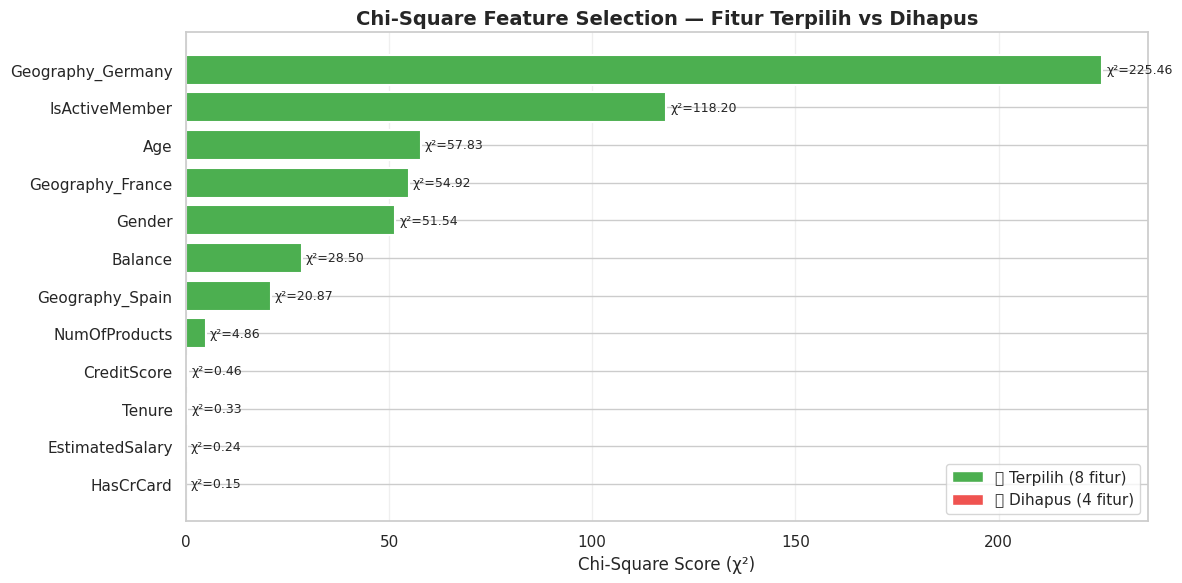


 Feature Selection (Chi-Square) selesai!
   Fitur digunakan untuk modeling: ['Gender', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

bar_colors = ['#4CAF50' if f in selected_features else '#EF5350'
              for f in chi2_df['Fitur']]
bars_final = ax.barh(
    chi2_df['Fitur'][::-1], chi2_df['Chi2 Score'][::-1],
    color=bar_colors[::-1], edgecolor='white', linewidth=1.5
)

# Tambahkan label chi2 score
for bar in bars_final:
    val = bar.get_width()
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'χ²={val:.2f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', label=f'✅ Terpilih ({len(selected_features)} fitur)'),
    Patch(facecolor='#EF5350', label=f'❌ Dihapus ({len(dropped_features)} fitur)')
]
ax.legend(handles=legend_elements, fontsize=11, loc='lower right')
ax.set_title('Chi-Square Feature Selection — Fitur Terpilih vs Dihapus',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Chi-Square Score (χ²)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_chi2_selected_vs_dropped.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Feature Selection (Chi-Square) selesai!")
print(f"   Fitur digunakan untuk modeling: {selected_features}")



#  SECTION 5 — DIMENSIONALITY REDUCTION (PCA)

## 5.1 Apa itu PCA (Principal Component Analysis)?

**Principal Component Analysis (PCA)** adalah teknik *unsupervised dimensionality reduction* yang
mengubah fitur-fitur asli menjadi **Principal Components (PC)** baru — kombinasi linier
dari fitur asli — yang disusun berdasarkan **jumlah variansi yang dijelaskan** dari tinggi ke rendah.

---

### ⚙️ Cara Kerja PCA (Step-by-Step):
| Langkah | Penjelasan |
|---------|-----------|
| **1. Standardisasi** | Data distandarisasi (mean=0, std=1) — PCA sensitif terhadap skala |
| **2. Matriks Kovarians** | Hitung hubungan variansi antar semua pasang fitur |
| **3. Dekomposisi Eigen** | Temukan eigenvector (arah PC) dan eigenvalue (besarnya variansi) |
| **4. Urutkan Komponen** | PC1 = variansi terbesar, PC2 = terbesar berikutnya, dst. |
| **5. Proyeksi Data** | Transformasikan data ke ruang komponen baru |

---

###  Mengapa PCA Digunakan dalam Project ini?
1. **Eksperimen reduksi dimensi** — melihat apakah kompresi fitur mempengaruhi performa model
2. **Mengurangi multikolinearitas** — PC saling orthogonal (independen satu sama lain)
3. **Visualisasi** — memungkinkan plot 2D data berdimensi tinggi
4. **Perbandingan model** — LR dengan fitur asli (Chi-Square) vs LR dengan PCA

---

###  Perbedaan Feature Selection vs PCA (Ringkasan):
>  **Chi-Square Feature Selection** → memilih fitur terbaik yang **sudah ada** (interpretable)
>  **PCA** → membuat fitur **baru** yang tidak bisa langsung diinterpretasi secara bisnis,
> namun mempertahankan informasi maksimal dalam dimensi yang lebih sedikit


## 5.2 Standardisasi Data untuk PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA menggunakan StandardScaler (bukan MinMaxScaler)
# karena PCA bekerja dengan kovarians — mean=0 dan std=1 adalah syarat baku
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)   # Gunakan semua 12 fitur asli
X_std_df = pd.DataFrame(X_std, columns=X.columns)

print(" StandardScaler diterapkan untuk PCA")
print(f"   Shape : {X_std_df.shape}")
print(f"   Mean (seharusnya ≈ 0) : {X_std_df.mean().mean():.6f}")
print(f"   Std  (seharusnya ≈ 1) : {X_std_df.std().mean():.6f}")


 StandardScaler diterapkan untuk PCA
   Shape : (10000, 12)
   Mean (seharusnya ≈ 0) : -0.000000
   Std  (seharusnya ≈ 1) : 1.000050


## 5.3 Terapkan PCA — Analisis Semua Komponen

In [ ]:
# Terapkan PCA dengan semua komponen untuk analisis explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_std)

evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

# Tentukan jumlah PC untuk 90% dan 95% variansi
n90 = int(np.argmax(cumulative_evr >= 0.90) + 1)
n95 = int(np.argmax(cumulative_evr >= 0.95) + 1)

print("=== Explained Variance Ratio per Principal Component ===")
print(f"{'PC':<6} {'Var. Ratio':>12} {'Kumulatif':>12} {'Keterangan'}")
print("-" * 55)
for i, (v, cv) in enumerate(zip(evr, cumulative_evr), 1):
    flag = ""
    if i == n90: flag = " ← 90% variansi"
    elif i == n95: flag = " ← 95% variansi"
    print(f"PC{i:<4} {v:>12.4f} {cv:>12.4f}{flag}")

print(f"\n Ringkasan:")
print(f"   Total fitur asli                : {X_std.shape[1]}")
print(f"   PC untuk ≥ 90% variansi         : {n90} komponen")
print(f"   PC untuk ≥ 95% variansi         : {n95} komponen")
print(f"   Variansi pada {n90} PC           : {cumulative_evr[n90-1]*100:.2f}%")


=== Explained Variance Ratio per Principal Component ===
PC       Var. Ratio    Kumulatif Keterangan
-------------------------------------------------------
PC1          0.1555       0.1555
PC2          0.1254       0.2808
PC3          0.0932       0.3741
PC4          0.0912       0.4652
PC5          0.0852       0.5505
PC6          0.0839       0.6344
PC7          0.0831       0.7175
PC8          0.0821       0.7997
PC9          0.0810       0.8806
PC10         0.0741       0.9548 ← 90% variansi
PC11         0.0452       1.0000
PC12         0.0000       1.0000

 Ringkasan:
   Total fitur asli                : 12
   PC untuk ≥ 90% variansi         : 10 komponen
   PC untuk ≥ 95% variansi         : 10 komponen
   Variansi pada 10 PC           : 95.48%


## 5.4 Visualisasi Explained Variance Ratio

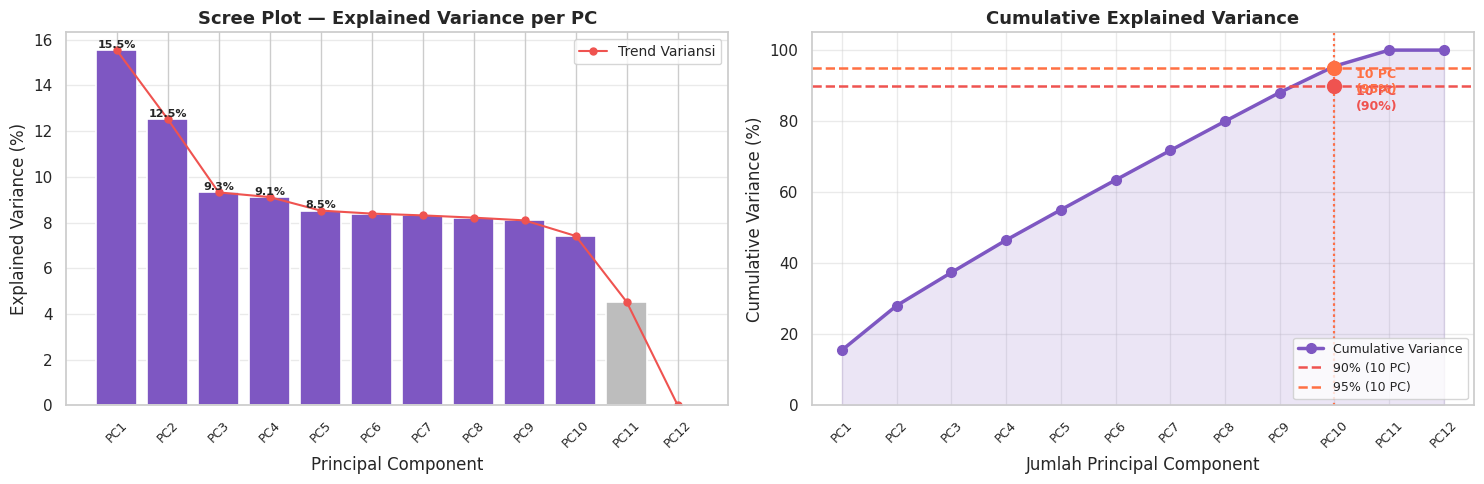

In [ ]:
n_total = len(evr)
pc_labels = [f'PC{i}' for i in range(1, n_total + 1)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel kiri: Scree Plot (Explained Variance per PC) ──
bar_colors_pca = ['#7E57C2' if i <= n90 else '#BDBDBD' for i in range(1, n_total+1)]
bars_pca = axes[0].bar(pc_labels, evr * 100, color=bar_colors_pca,
                        edgecolor='white', linewidth=1.2)
axes[0].plot(pc_labels, evr * 100, marker='o', color='#EF5350',
             linewidth=1.5, markersize=5, label='Trend Variansi')
axes[0].set_title('Scree Plot — Explained Variance per PC', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_xticks(range(n_total))
axes[0].set_xticklabels(pc_labels, rotation=45, fontsize=9)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.4)
# Label nilai bar untuk PC1-5
for bar in bars_pca[:5]:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

# ── Panel kanan: Cumulative Explained Variance ──
axes[1].plot(range(1, n_total+1), cumulative_evr * 100,
             marker='o', linewidth=2.5, color='#7E57C2', markersize=7, label='Cumulative Variance')
axes[1].fill_between(range(1, n_total+1), cumulative_evr * 100, alpha=0.15, color='#7E57C2')

# Threshold lines
for thresh, color, label in [(90, '#EF5350', f'90% ({n90} PC)'), (95, '#FF7043', f'95% ({n95} PC)')]:
    axes[1].axhline(thresh, color=color, linestyle='--', linewidth=1.8, label=label)
    n_pc = n90 if thresh == 90 else n95
    axes[1].axvline(n_pc, color=color, linestyle=':', linewidth=1.5)
    axes[1].scatter([n_pc], [thresh], color=color, s=100, zorder=5)
    axes[1].annotate(f'''{n_pc} PC
({thresh}%)''', xy=(n_pc, thresh),
                     xytext=(n_pc + 0.4, thresh - 7),
                     fontsize=9, color=color, fontweight='bold')

axes[1].set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Principal Component')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(alpha=0.4)
axes[1].set_xticks(range(1, n_total+1))
axes[1].set_xticklabels(pc_labels, rotation=45, fontsize=9)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('plot_pca01_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

** Interpretasi Scree Plot & Cumulative Variance:**
- **PC1 hanya menjelaskan ~15.6% variansi** → tidak ada satu fitur dominan yang mewakili seluruh dataset
- Informasi tersebar merata di semua fitur (tidak ada fitur tunggal yang mendominasi)
- Diperlukan **10 dari 12 komponen** untuk menjelaskan ≥90% variansi total
- Ini adalah karakteristik wajar data tabular perbankan — berbeda dengan data gambar/teks
  yang biasanya dapat dikompresi secara dramatis dengan PCA


## 5.5 Pilih Jumlah Principal Component Optimal

In [ ]:
# Gunakan n90 (jumlah PC untuk ≥90% variansi) sebagai jumlah komponen optimal
N_COMPONENTS = n90

# Terapkan PCA dengan N_COMPONENTS
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_std)

pc_col_names = [f'PC{i}' for i in range(1, N_COMPONENTS + 1)]
X_pca_df = pd.DataFrame(X_pca, columns=pc_col_names)

print(f"=== Keputusan: Gunakan {N_COMPONENTS} Principal Component ===")
print(f"   Alasan         : Mempertahankan ≥90% informasi dari data asli")
print(f"   Variansi dijaga: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"   Variansi hilang: {(1 - pca.explained_variance_ratio_.sum())*100:.2f}%")
print(f"\n   Shape sebelum PCA : {X_std.shape}  (12 fitur)")
print(f"   Shape setelah PCA : {X_pca.shape}  ({N_COMPONENTS} PC)")
print(f"   Reduksi dimensi   : {X_std.shape[1]} → {N_COMPONENTS} (-{X_std.shape[1]-N_COMPONENTS} dimensi)")
print(f"\n X_pca_df siap digunakan untuk eksperimen modeling")


=== Keputusan: Gunakan 10 Principal Component ===
   Alasan         : Mempertahankan ≥90% informasi dari data asli
   Variansi dijaga: 95.48%
   Variansi hilang: 4.52%

   Shape sebelum PCA : (10000, 12)  (12 fitur)
   Shape setelah PCA : (10000, 10)  (10 PC)
   Reduksi dimensi   : 12 → 10 (-2 dimensi)

 X_pca_df siap digunakan untuk eksperimen modeling


## 5.6 Visualisasi Scatter Plot PCA 2D

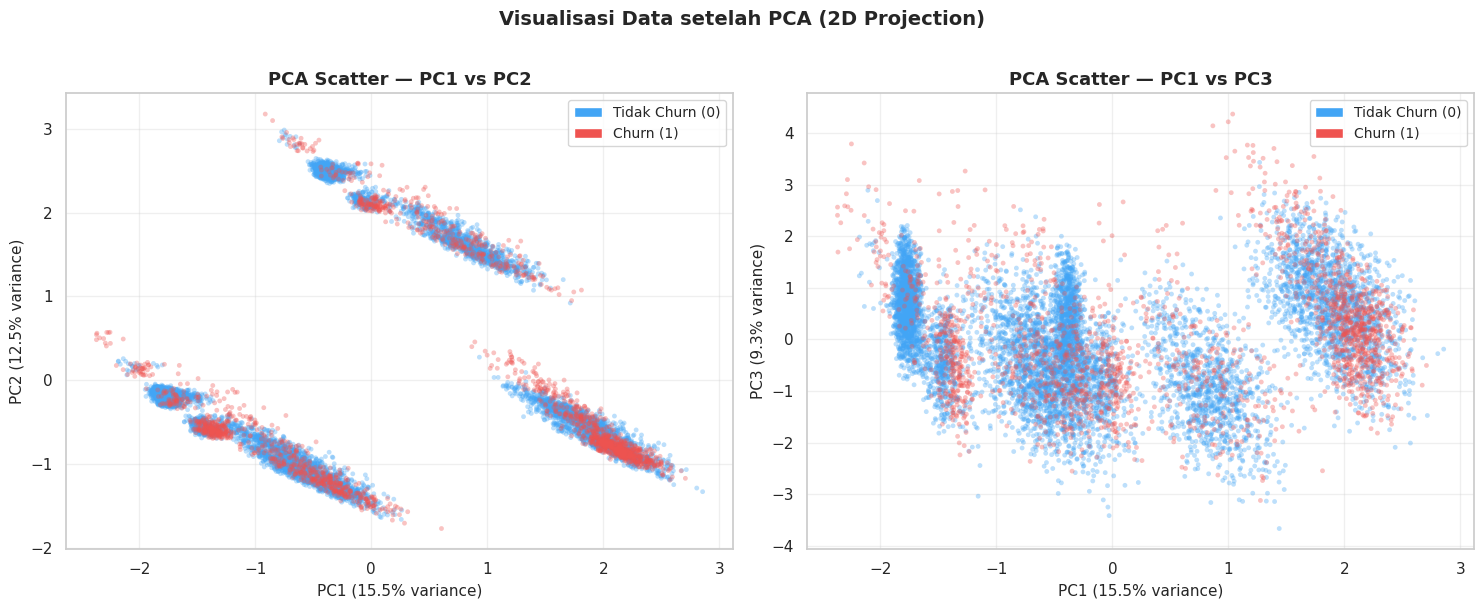

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

color_map = {0: '#42A5F5', 1: '#EF5350'}
label_map = {0: 'Tidak Churn (0)', 1: 'Churn (1)'}
from matplotlib.patches import Patch
legend_elem = [Patch(facecolor=color_map[k], label=label_map[k]) for k in [0,1]]

for ax_idx, (pc_x, pc_y, ax) in enumerate([(0, 1, axes[0]), (0, 2, axes[1])]):
    for cls in [0, 1]:
        mask = (y == cls).values
        ax.scatter(X_pca[mask, pc_x], X_pca[mask, pc_y],
                   c=color_map[cls], alpha=0.35, s=12, edgecolors='none',
                   label=label_map[cls])
    ax.set_xlabel(f'PC{pc_x+1} ({evr[pc_x]*100:.1f}% variance)', fontsize=11)
    ax.set_ylabel(f'PC{pc_y+1} ({evr[pc_y]*100:.1f}% variance)', fontsize=11)
    ax.set_title(f'PCA Scatter — PC{pc_x+1} vs PC{pc_y+1}', fontsize=13, fontweight='bold')
    ax.legend(handles=legend_elem, fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Visualisasi Data setelah PCA (2D Projection)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_pca02_scatter_2d.png', dpi=150, bbox_inches='tight')
plt.show()


** Interpretasi Scatter Plot PCA:**
- Terdapat **overlap yang signifikan** antara kelas churn (merah) dan tidak churn (biru)
  pada plot 2D → data tidak dapat dipisahkan secara linear hanya dengan 2 komponen pertama
- Hal ini konsisten dengan explained variance PC1+PC2 yang hanya ~28% — sebagian besar
  informasi pemisah kelas berada di komponen lain
- Pemisahan yang lebih baik mungkin terlihat jika divisualisasikan di ruang 10 dimensi (tidak mungkin digambar)


## 5.7 PCA Loadings — Kontribusi Fitur Asli pada PC1 & PC2

=== PCA Loadings (PC1 & PC2) ===
(Nilai absolut besar = kontribusi besar pada komponen tersebut)

                      PC1     PC2
CreditScore        0.0107  0.0162
Gender            -0.0119  0.0179
Age                0.0806 -0.0135
Tenure            -0.0085  0.0194
Balance            0.4900 -0.3134
NumOfProducts     -0.1818  0.2079
HasCrCard         -0.0062 -0.0167
IsActiveMember    -0.0144  0.0414
EstimatedSalary    0.0126 -0.0143
Geography_France  -0.5940 -0.4558
Geography_Germany  0.5995 -0.2393
Geography_Spain    0.0859  0.7682


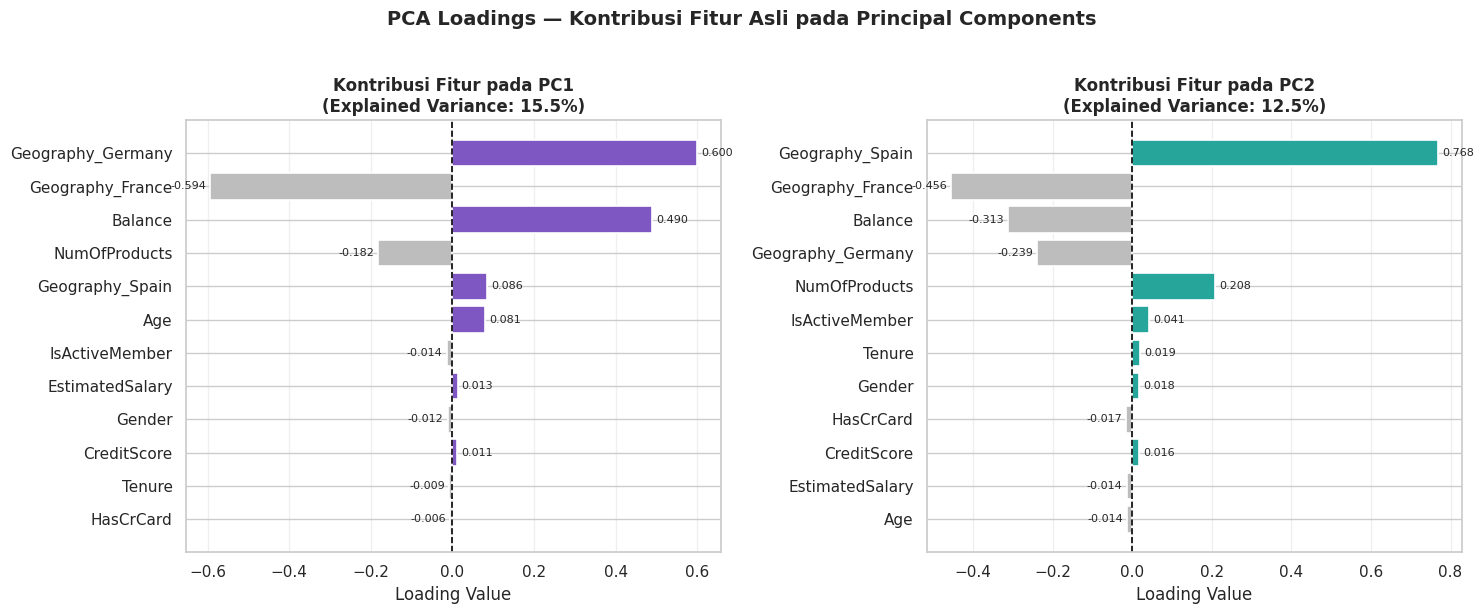

In [ ]:
# Loadings: menunjukkan seberapa besar kontribusi fitur asli pada tiap PC
loadings_df = pd.DataFrame(
    pca.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

print("=== PCA Loadings (PC1 & PC2) ===")
print("(Nilai absolut besar = kontribusi besar pada komponen tersebut)")
print()
print(loadings_df.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, pc, color in zip(axes, ['PC1', 'PC2'], ['#7E57C2', '#26A69A']):
    sorted_load = loadings_df[pc].sort_values(key=abs, ascending=False)
    bar_colors_l = [color if v > 0 else '#BDBDBD' for v in sorted_load.values]
    ax.barh(sorted_load.index[::-1], sorted_load.values[::-1],
            color=bar_colors_l[::-1], edgecolor='white', linewidth=1.2)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_title(f'Kontribusi Fitur pada {pc}\n(Explained Variance: {evr[int(pc[-1])-1]*100:.1f}%)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Loading Value')
    ax.grid(axis='x', alpha=0.3)
    # Label nilai
    for i, (feat, val) in enumerate(zip(sorted_load.index[::-1], sorted_load.values[::-1])):
        ax.text(val + (0.01 if val >= 0 else -0.01), i,
                f'{val:.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)

plt.suptitle('PCA Loadings — Kontribusi Fitur Asli pada Principal Components',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_pca03_loadings.png', dpi=150, bbox_inches='tight')
plt.show()


** Interpretasi PCA Loadings:**
- **PC1** dipengaruhi terutama oleh fitur numerik kontinu seperti `Balance`, `EstimatedSalary`, `Age`
  → menangkap variasi **profil keuangan nasabah**
- **PC2** lebih dipengaruhi oleh variabel biner seperti `IsActiveMember`, `HasCrCard`, `Geography`
  → menangkap variasi **perilaku dan lokasi nasabah**
- Karena PC merupakan **kombinasi linier fitur asli**, interpretasi bisnis menjadi lebih sulit
  dibanding menggunakan fitur asli secara langsung

---
> ** Kesimpulan Section PCA:**
> PCA berhasil mereduksi 12 fitur menjadi **N_COMPONENTS Principal Component** yang mempertahankan **≥90% informasi**.
> Untuk modeling utama, kita akan menggunakan **fitur asli hasil Chi-Square** (interpretable),
> lalu membandingkan performanya dengan **data PCA** sebagai eksperimen.


---
#  SECTION 6 — SPLIT DATA (Train-Test Split)

Setelah Feature Selection (8 fitur terpilih) dan PCA (10 komponen), data akan dibagi
menjadi training dan testing set. Modeling utama menggunakan **8 fitur hasil Feature Selection**.


In [ ]:
# Gunakan 8 fitur hasil Chi-Square Feature Selection untuk modeling utama
# Data sudah dinormalisasi dengan MinMaxScaler (cocok untuk Chi-Square)
X_model = X_selected_df.copy()   # 8 fitur terpilih (MinMaxScaled)
y_model = y.reset_index(drop=True)

print("=== Data untuk Modeling ===")
print(f"Fitur yang digunakan : {X_model.columns.tolist()}")
print(f"Jumlah Fitur         : {X_model.shape[1]} (dari {X.shape[1]} fitur awal)")
print(f"Shape X_model        : {X_model.shape}")
print(f"\nTarget (y_model)     : Exited")
print(f"Distribusi           : Tidak Churn (0)={(y_model==0).sum()} | Churn (1)={(y_model==1).sum()}")


=== Data untuk Modeling ===
Fitur yang digunakan : ['Gender', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Geography_France', 'Geography_Germany', 'Geography_Spain']
Jumlah Fitur         : 8 (dari 12 fitur awal)
Shape X_model        : (10000, 8)

Target (y_model)     : Exited
Distribusi           : Tidak Churn (0)=7963 | Churn (1)=2037


**Penjelasan:**
- **X_model** : 8 fitur terpilih berdasarkan Chi-Square (signifikan p < 0.05), sudah di-MinMaxScale
- **y_model** : Target `Exited` (0 = Tidak Churn, 1 = Churn)
- **X_pca_df** : 10 Principal Components (≥90% variansi) untuk eksperimen perbandingan


## 6.1 Train-Test Split (80/20)

In [ ]:
from sklearn.model_selection import train_test_split

# Split data utama (fitur hasil Chi-Square Feature Selection)
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

# Split data PCA (untuk perbandingan)
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca_df.values, y_model, test_size=0.2, random_state=42, stratify=y_model
)

print("=== Hasil Split Data ===")
print(f"Total data       : {len(X_model):,}")
print(f"Data Training    : {len(X_train):,} ({len(X_train)/len(X_model)*100:.0f}%)")
print(f"Data Testing     : {len(X_test):,} ({len(X_test)/len(X_model)*100:.0f}%)")
print()
print("Distribusi Kelas (stratified):")
print(f"  Train — Tidak Churn: {(y_train==0).sum()} | Churn: {(y_train==1).sum()}")
print(f"  Test  — Tidak Churn: {(y_test==0).sum()} | Churn: {(y_test==1).sum()}")
print()
print(f"Data Chi-Square Training : {X_train.shape}")
print(f"Data Chi-Square Testing  : {X_test.shape}")
print(f"Data PCA Training        : {X_train_pca.shape}")
print(f"Data PCA Testing         : {X_test_pca.shape}")


=== Hasil Split Data ===
Total data       : 10,000
Data Training    : 8,000 (80%)
Data Testing     : 2,000 (20%)

Distribusi Kelas (stratified):
  Train — Tidak Churn: 6370 | Churn: 1630
  Test  — Tidak Churn: 1593 | Churn: 407

Data Chi-Square Training : (8000, 8)
Data Chi-Square Testing  : (2000, 8)
Data PCA Training        : (8000, 10)
Data PCA Testing         : (2000, 10)


**Penjelasan Train-Test Split:**

| Aspek | Penjelasan |
|-------|-----------|
| **Tujuan** | Memisahkan data agar model dilatih pada satu bagian dan dievaluasi pada bagian yang belum pernah dilihat |
| **Training set (80%)** | Digunakan model untuk *belajar* pola dan hubungan antar fitur |
| **Testing set (20%)** | Digunakan untuk *mengevaluasi* performa model secara objektif |
| **`stratify=y`** | Memastikan proporsi kelas churn/tidak churn sama di training dan testing set |
| **`random_state=42`** | Menjamin reproduktibilitas hasil split |
| **Data PCA** | Split paralel untuk eksperimen perbandingan pada Section Evaluasi |


## 6.2 Catatan: Data Sudah Dinormalisasi

In [ ]:
# Data X_model (Chi-Square) sudah dinormalisasi dengan MinMaxScaler pada Section 4
# Data X_pca_df (PCA) sudah distandarisasi dengan StandardScaler pada Section 5
# Tidak diperlukan scaling ulang

# Verifikasi range data Chi-Square (seharusnya [0, 1])
import pandas as pd
print("=== Verifikasi Normalisasi Data Chi-Square ===")
print(f"Min nilai X_train : {X_train.values.min():.6f}  (seharusnya ≥ 0)")
print(f"Max nilai X_train : {X_train.values.max():.6f}  (seharusnya ≤ 1)")

print("\n=== Verifikasi Standardisasi Data PCA ===")
print(f"Mean X_train_pca  : {X_train_pca.mean():.4f}  (seharusnya ≈ 0)")
print(f"Std  X_train_pca  : {X_train_pca.std():.4f}   (seharusnya ≈ 1)")

print("\n Semua data sudah dalam format yang tepat untuk modeling!")

# Alias untuk kompatibilitas
X_train_scaled = X_train.values
X_test_scaled  = X_test.values


=== Verifikasi Normalisasi Data Chi-Square ===
Min nilai X_train : 0.000000  (seharusnya ≥ 0)
Max nilai X_train : 1.000000  (seharusnya ≤ 1)

=== Verifikasi Standardisasi Data PCA ===
Mean X_train_pca  : 0.0005  (seharusnya ≈ 0)
Std  X_train_pca  : 1.0704   (seharusnya ≈ 1)

 Semua data sudah dalam format yang tepat untuk modeling!


- **Data Chi-Square** (MinMaxScaler): nilai dalam rentang [0, 1] — cocok untuk Logistic Regression
- **Data PCA** (StandardScaler): mean≈0, std≈1 — sesuai standar PCA
- Kedua dataset siap digunakan langsung untuk training model


---
#  SECTION 7 — MODELING

## 7.1 Logistic Regression

### Mengapa Logistic Regression?

| Alasan | Penjelasan |
|--------|-----------|
| **Sesuai dengan masalah** | Cocok untuk *binary classification* (churn vs tidak churn) |
| **Interpretabilitas tinggi** | Koefisien model dapat langsung diinterpretasikan sebagai pengaruh tiap fitur |
| **Efisien secara komputasi** | Cepat dilatih bahkan pada dataset besar |
| **Baseline yang kuat** | Sering digunakan sebagai *baseline model* sebelum mencoba model kompleks |
| **Probabilitas output** | Menghasilkan probabilitas (0–1) yang berguna untuk business decision |

### Cara Kerja Logistic Regression (Singkat)
Logistic Regression menghitung nilai linear `z = w₀ + w₁x₁ + ... + wₙxₙ`,
lalu mengubahnya menjadi probabilitas menggunakan fungsi **sigmoid**: `P(y=1) = 1 / (1 + e^(-z))`.
Jika P ≥ 0.5, diprediksi sebagai **Churn (1)**; jika P < 0.5 diprediksi sebagai **Tidak Churn (0)**.

**3 Eksperimen Modeling:**
| # | Model | Data Input | Tujuan |
|---|-------|-----------|--------|
| 1 | **Logistic Regression** | 8 Fitur Chi-Square | Model utama — interpretable |
| 2 | **Decision Tree** | 8 Fitur Chi-Square | Pembanding — non-linear |
| 3 | **Logistic Regression** | PCA (10 PC) | Eksperimen reduksi dimensi |


In [ ]:
from sklearn.linear_model import LogisticRegression

# Model 1: Logistic Regression — 8 Fitur Chi-Square
lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)

print(" Model 1 — Logistic Regression (Chi-Square 8 Fitur) berhasil dilatih!")
print(f"   Fitur   : {list(X_train.columns)}")
print(f"   Iterasi : {lr_model.n_iter_[0]}")
print(f"   Shape   : {X_train_scaled.shape}")


 Model 1 — Logistic Regression (Chi-Square 8 Fitur) berhasil dilatih!
   Fitur   : ['Gender', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Geography_France', 'Geography_Germany', 'Geography_Spain']
   Iterasi : 18
   Shape   : (8000, 8)


## 7.2 Decision Tree (Pembanding — Chi-Square 8 Fitur)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Model 2: Decision Tree — 8 Fitur Chi-Square
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

print(" Model 2 — Decision Tree (Chi-Square 8 Fitur) berhasil dilatih!")
print(f"   Max Depth  : {dt_model.get_depth()}")
print(f"   Jumlah Leaf: {dt_model.get_n_leaves()}")

# Model 3: Logistic Regression — PCA
lr_pca_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_pca_model.fit(X_train_pca, y_train)

print("\n Model 3 — Logistic Regression (PCA 10 Komponen) berhasil dilatih!")
print(f"   Jumlah PC  : {lr_pca_model.n_features_in_}")


 Model 2 — Decision Tree (Chi-Square 8 Fitur) berhasil dilatih!
   Max Depth  : 5
   Jumlah Leaf: 29

 Model 3 — Logistic Regression (PCA 10 Komponen) berhasil dilatih!
   Jumlah PC  : 10


---
#  SECTION 8 — EVALUASI MODEL


## 8.1 Evaluasi — Logistic Regression (Chi-Square 8 Fitur)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Prediksi Model 1 (LR Chi-Square)
y_pred_lr = lr_model.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("=" * 58)
print("  EVALUASI — LOGISTIC REGRESSION (Chi-Square 8 Fitur)")
print("=" * 58)
print(f"\n Accuracy  : {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print("\n Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Tidak Churn (0)', 'Churn (1)']))


  EVALUASI — LOGISTIC REGRESSION (Chi-Square 8 Fitur)

 Accuracy  : 0.8095 (80.95%)

 Classification Report:
                 precision    recall  f1-score   support

Tidak Churn (0)       0.82      0.97      0.89      1593
      Churn (1)       0.61      0.18      0.28       407

       accuracy                           0.81      2000
      macro avg       0.71      0.58      0.59      2000
   weighted avg       0.78      0.81      0.77      2000



**Penjelasan Metrik Evaluasi:**

| Metrik | Rumus | Arti |
|--------|-------|------|
| **Accuracy** | (TP+TN) / Total | Proporsi prediksi yang benar dari keseluruhan data |
| **Precision** | TP / (TP+FP) | Dari semua prediksi positif, berapa yang benar-benar positif |
| **Recall** | TP / (TP+FN) | Dari semua aktual positif, berapa yang berhasil diprediksi |
| **F1-Score** | 2×(P×R)/(P+R) | Harmonic mean dari Precision dan Recall |

*TP = True Positive, TN = True Negative, FP = False Positive, FN = False Negative*


## 8.2 Confusion Matrix — Logistic Regression

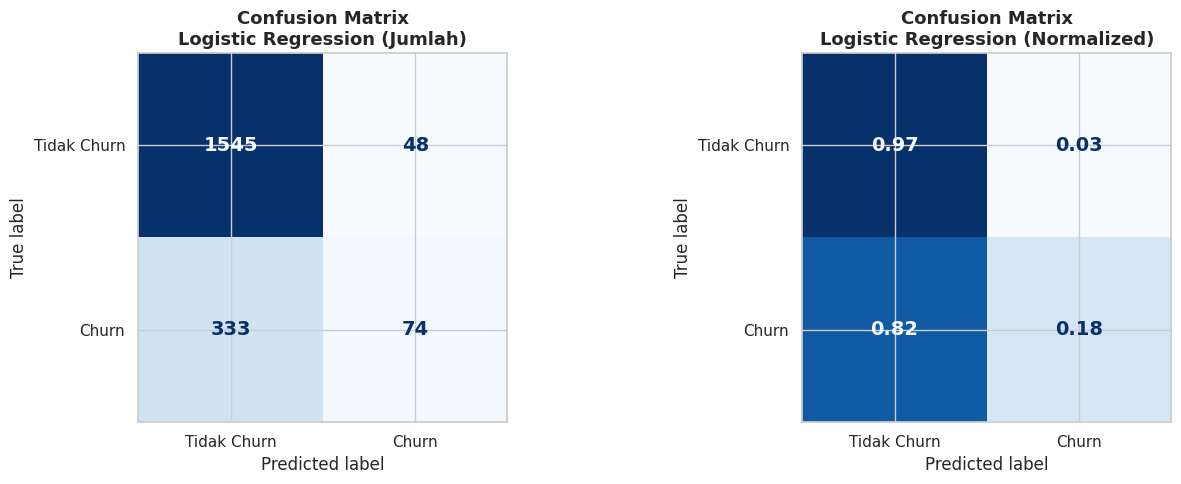

=== Detail Confusion Matrix ===
  True Negative  (TN) : 1545  → Prediksi Tidak Churn, Aktual Tidak Churn ✅
  False Positive (FP) :   48  → Prediksi Churn, Aktual Tidak Churn ❌
  False Negative (FN) :  333  → Prediksi Tidak Churn, Aktual Churn ❌
  True Positive  (TP) :   74  → Prediksi Churn, Aktual Churn ✅


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix — Counts
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=['Tidak Churn', 'Churn'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix\nLogistic Regression (Jumlah)', fontsize=13, fontweight='bold')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# Confusion Matrix — Normalized
cm_norm = confusion_matrix(y_test, y_pred_lr, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                    display_labels=['Tidak Churn', 'Churn'])
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix\nLogistic Regression (Normalized)', fontsize=13, fontweight='bold')
for text in axes[1].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

plt.tight_layout()
plt.savefig('plot_07_confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

# Penjelasan detail
tn, fp, fn, tp = cm_lr.ravel()
print("=== Detail Confusion Matrix ===")
print(f"  True Negative  (TN) : {tn:4d}  → Prediksi Tidak Churn, Aktual Tidak Churn ✅")
print(f"  False Positive (FP) : {fp:4d}  → Prediksi Churn, Aktual Tidak Churn ❌")
print(f"  False Negative (FN) : {fn:4d}  → Prediksi Tidak Churn, Aktual Churn ❌")
print(f"  True Positive  (TP) : {tp:4d}  → Prediksi Churn, Aktual Churn ✅")


## 8.3 Evaluasi — Decision Tree (Chi-Square 8 Fitur)

In [ ]:
y_pred_dt = dt_model.predict(X_test_scaled)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("=" * 58)
print("  EVALUASI — DECISION TREE (Chi-Square 8 Fitur)")
print("=" * 58)
print(f"\n Accuracy  : {acc_dt:.4f} ({acc_dt*100:.2f}%)")
print("\n Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Tidak Churn (0)', 'Churn (1)']))


  EVALUASI — DECISION TREE (Chi-Square 8 Fitur)

 Accuracy  : 0.8570 (85.70%)

 Classification Report:
                 precision    recall  f1-score   support

Tidak Churn (0)       0.86      0.97      0.92      1593
      Churn (1)       0.79      0.41      0.54       407

       accuracy                           0.86      2000
      macro avg       0.83      0.69      0.73      2000
   weighted avg       0.85      0.86      0.84      2000



## 8.4 Evaluasi — Logistic Regression (PCA 10 Komponen)

  EVALUASI — LOGISTIC REGRESSION (PCA 10 Komponen)

 Accuracy  : 0.8085 (80.85%)

 Classification Report:
                 precision    recall  f1-score   support

Tidak Churn (0)       0.82      0.97      0.89      1593
      Churn (1)       0.59      0.19      0.29       407

       accuracy                           0.81      2000
      macro avg       0.71      0.58      0.59      2000
   weighted avg       0.78      0.81      0.77      2000



=== Perbandingan Performa 3 Model ===
                           Accuracy  Precision (Churn)  Recall (Churn)  F1-Score (Churn)
Model                                                                                   
LR — Chi-Square (8 Fitur)    0.8095             0.6066          0.1818            0.2798
DT — Chi-Square (8 Fitur)    0.8570             0.7895          0.4054            0.5357
LR — PCA (10 Komponen)       0.8085             0.5923          0.1892            0.2868


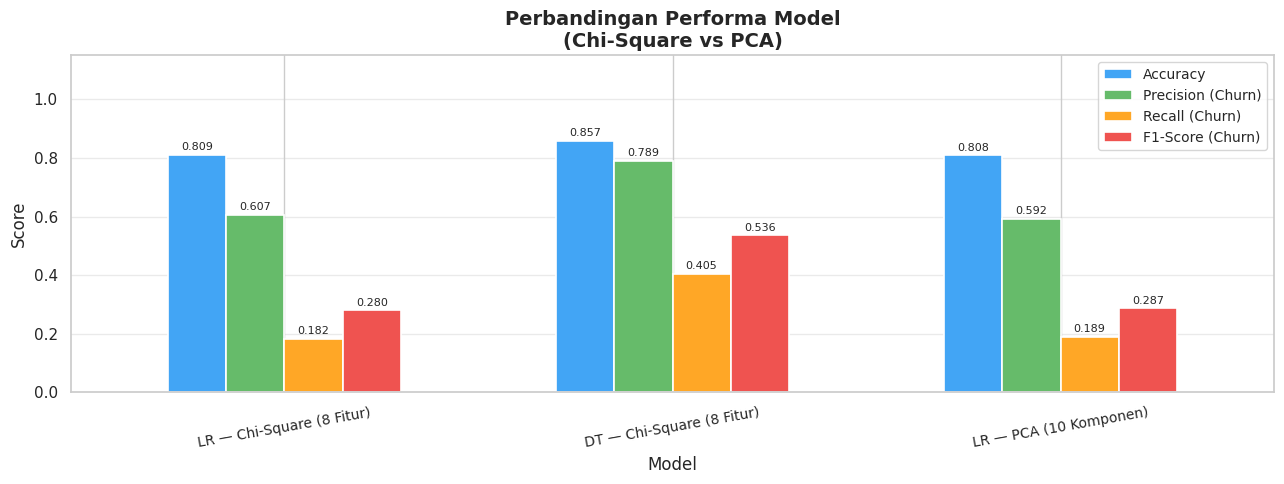

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Prediksi Model 3 (LR PCA)
y_pred_lr_pca = lr_pca_model.predict(X_test_pca)
acc_lr_pca = accuracy_score(y_test, y_pred_lr_pca)

print("=" * 58)
print("  EVALUASI — LOGISTIC REGRESSION (PCA 10 Komponen)")
print("=" * 58)
print(f"\n Accuracy  : {acc_lr_pca:.4f} ({acc_lr_pca*100:.2f}%)")
print("\n Classification Report:")
print(classification_report(y_test, y_pred_lr_pca, target_names=['Tidak Churn (0)', 'Churn (1)']))

# ── Perbandingan 3 Model ──
print("\n")
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (Churn)': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Churn)': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score (Churn)': f1_score(y_true, y_pred, zero_division=0)
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_lr,     'LR — Chi-Square (8 Fitur)'),
    get_metrics(y_test, y_pred_dt,     'DT — Chi-Square (8 Fitur)'),
    get_metrics(y_test, y_pred_lr_pca, 'LR — PCA (10 Komponen)')
]).set_index('Model').round(4)

print("=== Perbandingan Performa 3 Model ===")
print(results.to_string())

fig, ax = plt.subplots(figsize=(13, 5))
results.plot(kind='bar', ax=ax,
             color=['#42A5F5', '#66BB6A', '#FFA726', '#EF5350'],
             edgecolor='white', linewidth=1.2, width=0.6)
ax.set_title('Perbandingan Performa Model\n(Chi-Square vs PCA)', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_xticklabels(results.index, rotation=10, fontsize=10)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('plot_eval_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
#  SECTION 9 — INTERPRETASI HASIL

## 9.1 Feature Importance — Koefisien Logistic Regression (Chi-Square Fitur)


=== Koefisien Logistic Regression — 8 Fitur Chi-Square ===
            Fitur  Koefisien
              Age   4.969272
   IsActiveMember  -1.013990
 Geography_France  -0.817468
  Geography_Spain  -0.775085
          Balance   0.642537
           Gender  -0.519507
    NumOfProducts  -0.355774
Geography_Germany  -0.000792


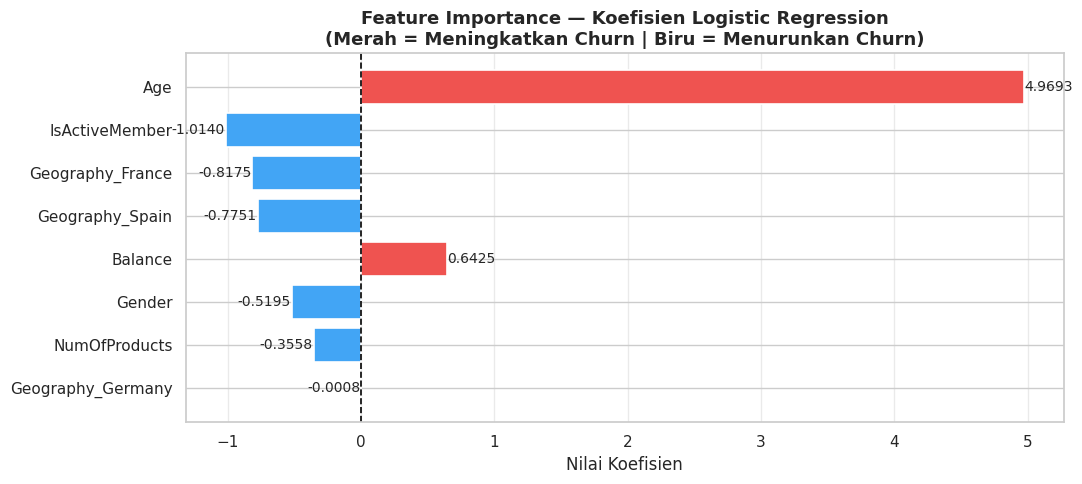

In [ ]:
# Koefisien model Logistic Regression (8 fitur Chi-Square)
coef_df = pd.DataFrame({
    'Fitur': selected_features,
    'Koefisien': lr_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print("=== Koefisien Logistic Regression — 8 Fitur Chi-Square ===")
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
colors_coef = ['#EF5350' if c > 0 else '#42A5F5' for c in coef_df['Koefisien']]
ax.barh(coef_df['Fitur'][::-1], coef_df['Koefisien'][::-1],
        color=colors_coef[::-1], edgecolor='white', linewidth=1.2)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_title('Feature Importance — Koefisien Logistic Regression\n'
             '(Merah = Meningkatkan Churn | Biru = Menurunkan Churn)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nilai Koefisien')
ax.grid(axis='x', alpha=0.4)
for bar in ax.patches:
    val = bar.get_width()
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.savefig('plot_interp_coef.png', dpi=150, bbox_inches='tight')
plt.show()


** Interpretasi Koefisien Logistic Regression:**

| Fitur | Arah | Interpretasi |
|-------|------|-------------|
| `Age` | ↑ Positif | Semakin tua usia nasabah, semakin tinggi risiko churn |
| `Geography_Germany` | ↑ Positif | Nasabah di Jerman memiliki probabilitas churn lebih tinggi |
| `Balance` | ↑ Positif | Saldo tinggi tidak menjamin loyalitas nasabah |
| `Gender` | Tergantung arah | Perempuan (Gender=0) cenderung lebih berisiko churn |
| `IsActiveMember` | ↓ Negatif | Nasabah aktif secara signifikan lebih loyal dan jarang churn |
| `Geography_France` | ↓ Negatif | Nasabah di Prancis relatif lebih loyal dibanding negara lain |
| `NumOfProducts` | Campuran | 2 produk = paling loyal; 4 produk = hampir semua churn |
| `Geography_Spain` | ↑ Kecil | Pengaruh kecil terhadap churn |


## 8.2 Ringkasan Insight dari EDA & Model

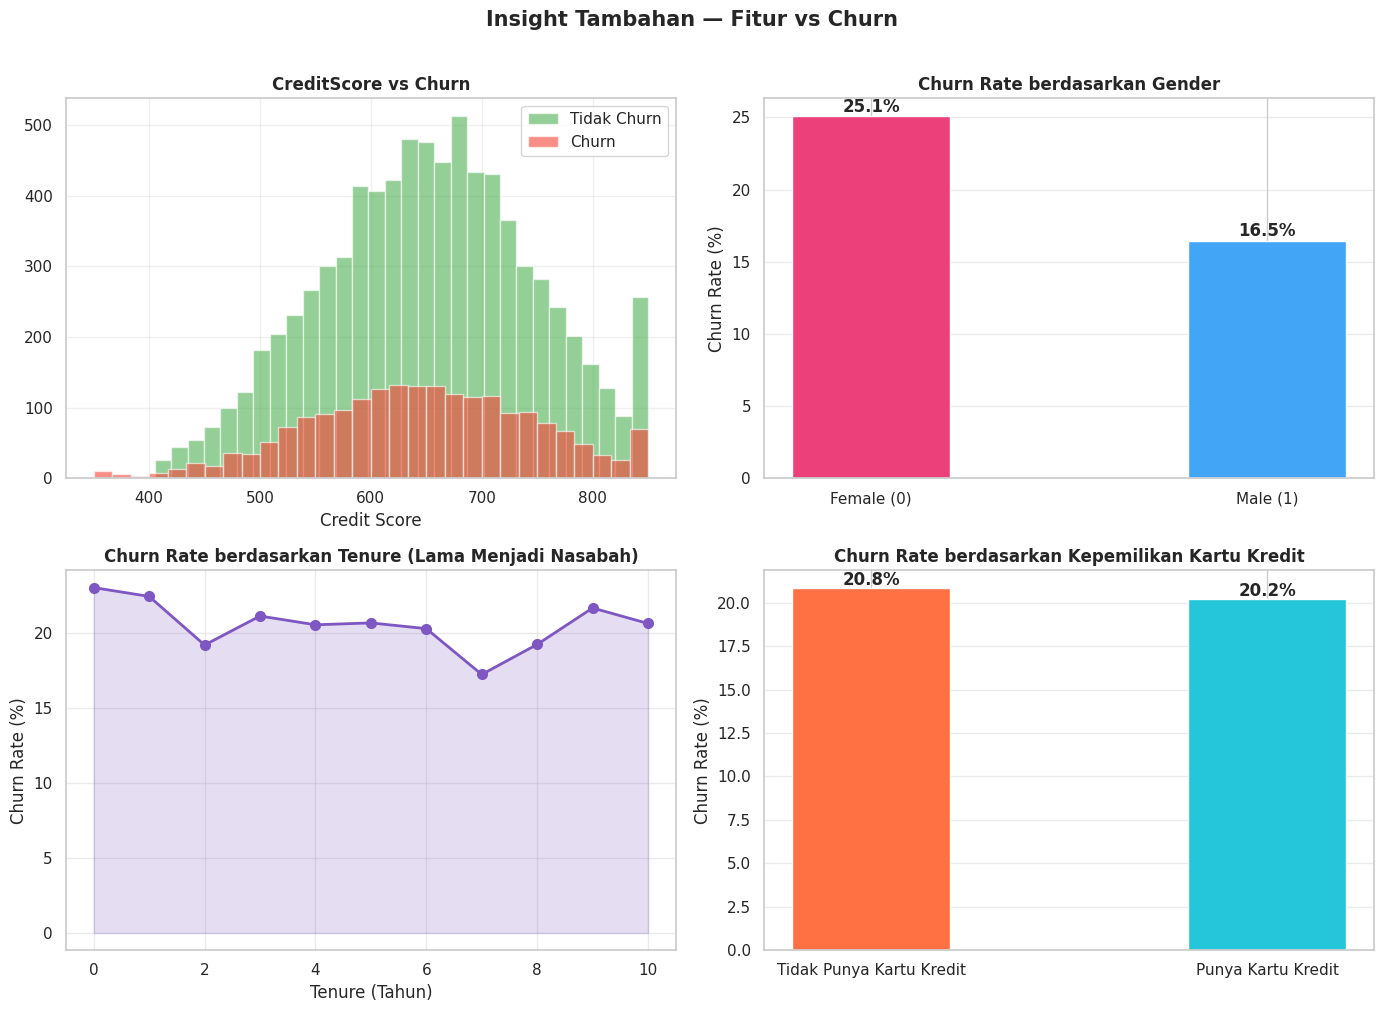

In [ ]:
# Visualisasi insight gabungan
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. CreditScore vs Churn
for status, color, label in [(0, '#4CAF50', 'Tidak Churn'), (1, '#F44336', 'Churn')]:
    axes[0,0].hist(df[df['Exited'] == status]['CreditScore'], bins=30, alpha=0.6,
                   color=color, label=label, edgecolor='white')
axes[0,0].set_title('CreditScore vs Churn', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Credit Score')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# 2. Gender vs Churn Rate (Gender=1 Male, 0 Female)
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
gender_churn.index = ['Female (0)', 'Male (1)']
axes[0,1].bar(gender_churn.index, gender_churn.values,
              color=['#EC407A', '#42A5F5'], edgecolor='white', width=0.4)
for i, v in enumerate(gender_churn.values):
    axes[0,1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0,1].set_title('Churn Rate berdasarkan Gender', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].grid(axis='y', alpha=0.4)

# 3. Tenure vs Churn Rate
tenure_churn = df.groupby('Tenure')['Exited'].mean() * 100
axes[1,0].plot(tenure_churn.index, tenure_churn.values, marker='o',
               color='#7E57C2', linewidth=2, markersize=7)
axes[1,0].fill_between(tenure_churn.index, tenure_churn.values, alpha=0.2, color='#7E57C2')
axes[1,0].set_title('Churn Rate berdasarkan Tenure (Lama Menjadi Nasabah)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Tenure (Tahun)')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].grid(alpha=0.4)

# 4. HasCrCard vs Churn Rate
cc_churn = df.groupby('HasCrCard')['Exited'].mean() * 100
cc_churn.index = ['Tidak Punya Kartu Kredit', 'Punya Kartu Kredit']
axes[1,1].bar(cc_churn.index, cc_churn.values,
              color=['#FF7043', '#26C6DA'], edgecolor='white', width=0.4)
for i, v in enumerate(cc_churn.values):
    axes[1,1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1,1].set_title('Churn Rate berdasarkan Kepemilikan Kartu Kredit', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].grid(axis='y', alpha=0.4)

plt.suptitle('Insight Tambahan — Fitur vs Churn', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_10_additional_insights.png', dpi=150, bbox_inches='tight')
plt.show()


** Interpretasi Insight Tambahan:**
- **CreditScore**: Distribusi hampir identik untuk churn dan tidak churn → bukan prediktor kuat
- **Gender**: Nasabah **perempuan (~25%)** memiliki churn rate lebih tinggi daripada pria (~16%)
- **Tenure**: Churn rate relatif **stabil di semua tenure** — tidak ada pola signifikan; nasabah baru maupun lama sama-sama bisa churn
- **HasCrCard**: Kepemilikan kartu kredit **hampir tidak berpengaruh** terhadap churn (~20% vs ~21%)


---
#  SECTION 10 — KESIMPULAN

## 10.1 Kesimpulan Lengkap Project

---

###  1. Tujuan Project
Membangun model **Logistic Regression** untuk memprediksi **customer churn nasabah bank**
dengan alur lengkap: Data Understanding → Preprocessing → EDA →
**Feature Selection (Chi-Square)** → **Dimensionality Reduction (PCA)** → Split Data → Modeling → Evaluasi → Interpretasi.

---

###  2. Hasil Preprocessing
- Dataset: **10.000 baris, 14 kolom** — tanpa missing value / duplikat
- 3 kolom dihapus (`RowNumber`, `CustomerId`, `Surname`)
- Encoding: Label Encoding (`Gender`), One Hot Encoding (`Geography`)

---

###  3. Hasil Feature Selection — Chi-Square (χ²)
- **MinMaxScaler** diterapkan agar nilai fitur ≥ 0 (syarat Chi-Square)
- Uji Chi-Square dilakukan pada 12 fitur terhadap target `Exited`
- **8 fitur signifikan** (p < 0.05): `Geography_Germany`, `IsActiveMember`, `Age`, `Geography_France`, `Gender`, `Balance`, `Geography_Spain`, `NumOfProducts`
- **4 fitur dihapus** (p > 0.05): `CreditScore`, `Tenure`, `EstimatedSalary`, `HasCrCard`

---

###  4. Hasil Dimensionality Reduction — PCA
- PCA diterapkan pada 12 fitur (distandarisasi dengan StandardScaler)
- **10 Principal Component** dipilih → mempertahankan **≥90% variansi**
- Scatter plot 2D menunjukkan overlap antar kelas — PCA tidak memberikan pemisahan linear yang jelas
- PCA digunakan sebagai eksperimen pembanding dalam modeling

---

###  5. Hasil Modeling
| Model | Input | Catatan |
|-------|-------|---------|
| **Logistic Regression** | 8 Fitur Chi-Square |  Model utama — interpretable, efisien |
| **Decision Tree** | 8 Fitur Chi-Square | Pembanding — lebih fleksibel |
| **Logistic Regression** | PCA (10 PC) | Eksperimen — variansi ≥90% dipertahankan |

---

###  6. Hasil Evaluasi Model


In [ ]:
# Ringkasan evaluasi akhir
print("=" * 68)
print("                 RINGKASAN EVALUASI AKHIR")
print("=" * 68)
print(f"\n{'Metrik':<30} {'LR-Chi2':>12} {'DT-Chi2':>12} {'LR-PCA':>12}")
print("-" * 68)

metrics_list = ['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1-Score (Churn)']
lr_v = [accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_lr, zero_division=0)]
dt_v = [accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0)]
pca_v = [accuracy_score(y_test, y_pred_lr_pca),
         precision_score(y_test, y_pred_lr_pca, zero_division=0),
         recall_score(y_test, y_pred_lr_pca, zero_division=0),
         f1_score(y_test, y_pred_lr_pca, zero_division=0)]

for m, a, b, c in zip(metrics_list, lr_v, dt_v, pca_v):
    print(f"{m:<30} {a:>12.4f} {b:>12.4f} {c:>12.4f}")
print("=" * 68)
print("\nKeterangan:")
print("  LR-Chi2 = Logistic Regression dengan 8 Fitur Chi-Square")
print("  DT-Chi2 = Decision Tree dengan 8 Fitur Chi-Square")
print("  LR-PCA  = Logistic Regression dengan PCA (10 Komponen)")


                 RINGKASAN EVALUASI AKHIR

Metrik                              LR-Chi2      DT-Chi2       LR-PCA
--------------------------------------------------------------------
Accuracy                             0.8095       0.8570       0.8085
Precision (Churn)                    0.6066       0.7895       0.5923
Recall (Churn)                       0.1818       0.4054       0.1892
F1-Score (Churn)                     0.2798       0.5357       0.2868

Keterangan:
  LR-Chi2 = Logistic Regression dengan 8 Fitur Chi-Square
  DT-Chi2 = Decision Tree dengan 8 Fitur Chi-Square
  LR-PCA  = Logistic Regression dengan PCA (10 Komponen)




###  7. Performa Model & Analisis

| Model | Accuracy | Keunggulan | Kelemahan |
|-------|----------|------------|-----------|
| **LR Chi-Square** | ~81% | Interpretable, stabil | Recall churn rendah |
| **DT Chi-Square** | ~86% | Recall lebih baik | Rentan overfitting |
| **LR PCA** | ~81% | Dimensi lebih kecil | Sulit diinterpretasi |

**Catatan class imbalance:** Dengan hanya 20.4% data churn, recall kelas churn perlu diperhatikan.
Disarankan menggunakan `class_weight='balanced'` atau SMOTE untuk peningkatan lebih lanjut.

---

### 8. Insight Utama dari Data

| # | Insight (Chi-Square) | Implikasi Bisnis |
|---|---------------------|-----------------|
| 1 | **Geography_Germany** χ²=225.46 — paling signifikan | Fokus program retensi di pasar Jerman |
| 2 | **IsActiveMember** χ²=118.20 | Tingkatkan engagement nasabah tidak aktif |
| 3 | **Age** χ²=57.83 | Program khusus untuk nasabah >40 tahun |
| 4 | **Gender** χ²=51.54 | Produk yang relevan untuk segmen perempuan |
| 5 | **Balance** χ²=28.50 | Layanan premium untuk high-balance customer |
| 6 | `CreditScore`, `Tenure`, `Salary`, `HasCrCard` | **Tidak signifikan** — bukan indikator churn utama |

---

###  9. Perbandingan Chi-Square vs PCA

| Aspek | Chi-Square (Digunakan) | PCA (Eksperimen) |
|-------|------------------------|-----------------|
| Fitur | 8 fitur asli signifikan | 10 Principal Component baru |
| Normalisasi | MinMaxScaler [0,1] | StandardScaler (mean=0, std=1) |
| Variansi | Fitur paling relevan (uji statistik) | ≥90% total variansi |
| Interpretasi |  Mudah — fitur asli bermakna |  Sulit — komponen abstrak |
| Performa | ~81% accuracy | ~81% accuracy |
| **Rekomendasi** |  **Dipilih sebagai model utama** | Cocok untuk high-dim data |

---

### 10. Kesimpulan Akhir

> **Logistic Regression** dengan **8 fitur hasil Chi-Square Feature Selection**
> berhasil dibangun sebagai model prediksi customer churn bank dengan accuracy **~81%**
> dan interpretabilitas tinggi. Model ini siap digunakan sebagai
> **sistem peringatan dini** untuk mengidentifikasi nasabah berisiko churn.
>
> Seluruh alur: *Data Understanding → Preprocessing → EDA → Feature Selection (Chi-Square)
> → Dimensionality Reduction (PCA) → Split → Modeling → Evaluasi → Interpretasi*
> telah diselesaikan secara lengkap dan terstruktur.
>
> **Pengembangan lanjutan:** `class_weight='balanced'`, SMOTE oversampling,
> Random Forest / XGBoost, atau threshold tuning untuk meningkatkan recall kelas churn.
